<a id = "bookmark"></a>

#### Group-10: Take-Home Assignment

**[Project Team Members](#team)**

**[Problem Statement](#problem)**

**[Dependencies](#dependencies)**

**[Part-1](#part1)**

**Momemtum**
- [1.1 - Simple Moving Average Cross Over](#sma)
- [1.2 - Exponential Moving Average Cross Over](#ema)
- [1.3 - Moving Average Convergence Divergence](#macd)

**Mean Reversion**
- [1.4 - Relative Strength Index (RSI)](#rsi)
- [1.5 - Bollinger Bands](#bb)

**Machine Learning**
- [1.6 - Supervised ML (Regression based)](#regression)
- [1.7 - Unsupervised ML (PCA based)](#pca)

**[Part-2](#part2)**
- [2.1 Strategy Performance Evaluation](#performance)
- [2.2 Strategy Backtesting](#backtest)

**[Part-3](#part3)**
- [3.1 Linear Regression](#summary31)
- [3.2 Simple Moving Average Crossover](#summary32)
- [3.3 PCA](#summary33)
- [3.4 Bollinger Bands](#summary34)

**[Part-4](#part4)**
- [4.1 Momentum and Mean Reversion Critique](#critique41)
- [4.2 Machine Learning Critique](#critique42)
- [4.3 Contribution Statement](#contribution)


<a id="team"></a>
### Project Team Members
1. Hongyang Guan
2. Prakash Nirala
3. Rachel Yee
###### [Back to table of contents](#bookmark)

<a id="problem"></a>
### Problem Statement

You will build your trading strategy using the past 20 years `(November 2005 through October 2024)` of S&P 500 data, extracting the data from Yahoo Finance. Your `starting capital` is set at `$100,000`.

#### NOTE
- Please use the `SPY` ticker for your market baseline return and your strategy return for the period of November 2005 through October 2024. Your only asset is SPY itself—no composites, no sub-index, no sub-components.

- The starting capital of `$100,000` is the only capital you have, and the capital is for each strategy. You are not allowed to borrow any more money.

- Our operational definition of a better strategy, for the purpose of this assignment, is to `maximize your cumulative return.`

- In order to be fair, your work will be assessed based on what you have learned in the module. The question did not ask about anything outside the scripts of the course.

- For this take-home assignment, please remember that you are supposed to be comparing model strategy cumulative returns from different approaches (i.e., momentum, mean-reversion, machine learning).

- As mentioned in the question, and in the previous guideline note, this is for assessment of your mastery of knowledge learned in the course itself. This assignment assesses strategy, and nothing else (e.g., implementing stop-loss is not a part of it).

For this assignment:

Build your trading strategies using data from the first `80%` of the timeframe.
Use the most recent `20% of the timeframe for backtesting purposes`.

To reiterate, your submission will be assessed on:

1. the quality and validity of your programming (lines of codes);

2. your analysis of strategies (why certain strategies are better than others, and importantly, why they are better) and your recommendations (this is what quants do), and;

3. your group’s cumulative return relative to the other groups’ cumulative returns.

###### [Back to table of contents](#bookmark)

<a id="dependencies"></a>

### <font color="orange"> Dependencies </font>

###### [Back to table of contents](#bookmark)

In [196]:
import time
import re
import random
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.graph_objs as go

from itertools import product
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

np.set_printoptions(precision=3)
plt.style.use("ggplot")
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25
mpl.rcParams["axes.facecolor"] = "white"
mpl.rcParams["legend.fontsize"] = 14

In [197]:
start_date = dt.datetime(2005, 11, 1)
end_date = dt.datetime(2024, 11, 1)

spy_df = yf.download('SPY', start=start_date, end=end_date)[['Adj Close']]
spy_df

[*********************100%%**********************]  1 of 1 completed


,Adj Close
Date,
2005-11-01,83.991142
2005-11-02,84.869446
2005-11-03,85.231941
2005-11-04,85.120407
2005-11-07,85.204071
...,...
2024-10-25,579.039978
2024-10-28,580.830017
2024-10-29,581.770020


<a id="part1"></a>
### Part 1 (7 points)
First, you should build a series of trading strategies employing `momentum`, `mean-reversion`, and `machine learning` approaches. As you have learned, within each approach, you could come up with varying strategies depending on how you define them. Here, think about how you’d like to do this in a more efficient and effective manner, building on what you have learned about Python programming throughout the course.

* Basic Momentum, Mean Reversion strategies taught in class
* Integrating Trading Strategies: You have the option to combine mean reversion and momentum strategies in your algorithmic trading models. Indicators like the Moving Average Convergence Divergence (MACD) and the Relative Strength Index (RSI) can be effectively used to generate buy and sell signals. Leveraging the unique principles of each concept and indicator can contribute to a more comprehensive trading strategy. 
* Machine Learning in Strategy Allocation: You may use machine learning techniques to enhance economic-based trading strategies, such as determining the balance between momentum and mean reversion strategies.
* Technical Indicators for Trading Signals: You may explore and utilize a wide range of technical indicators, such as the KDJ (K-line/D-line/J-line) indicator, to construct your trading signals. These indicators can provide valuable insights into market trends, momentum, and potential reversal points, which are crucial in developing effective trading strategies. Note that the choice of indicators should align with the specific objectives and constraints of your trading model.
###### [Back to table of contents](#bookmark)

In [198]:
# Function used for hyperparameter tuning
def evaluate_strategy(returns):
    
    def calc_sharpe_ratio(returns):
        simple_ret = np.exp(returns) - 1
        mean_ret = simple_ret.mean()
        std_ret = simple_ret.std()
        return mean_ret/std_ret * np.sqrt(252)

    def calc_total_returns(returns):
        return np.exp(returns.sum())
    
    sharpe = calc_sharpe_ratio(returns)
    total = calc_total_returns(returns)
    return total, sharpe

### Momentum

<a id="sma"></a>

#### <font color="orange"> Part 1.1 - Simple Moving Average Cross Over (Long-Short)</font>

###### [Back to table of contents](#bookmark)

In [199]:
# SMA strategy

def SMA_strategy(data, short_window, long_window):
    df = pd.DataFrame(index=data.index)

    df["Adj Close"] = data["Adj Close"]

    df["short_SMA"] = (
        data["Adj Close"]
        .rolling(window=short_window, min_periods=1, center=False)
        .mean()
    )
    df["long_SMA"] = (
        data["Adj Close"]
        .rolling(window=long_window, min_periods=1, center=False)
        .mean()
    )

    df["Positions"] = np.nan
    df["Positions"][short_window:] = np.where(df["short_SMA"][short_window:] > df["long_SMA"][short_window:], 1.0, -1.0)

    df["log_returns"] = np.log(data["Adj Close"] / data["Adj Close"].shift(1))
    df["strategy_log_returns"] = df["log_returns"] * df["Positions"].shift(1)

    return df

In [200]:
# Hyperparameter tuning for SMA
short_windows = range(5, 201, 1)   # Short SMA windows
long_windows = range(20, 301, 1)  # Long SMA windows
results = []

for short_window, long_window in tqdm(product(short_windows, long_windows), total=len(short_windows) * len(long_windows)):
    if short_window >= long_window:
        continue  # Skip invalid pairs
    strategy_data = SMA_strategy(spy_df, short_window, long_window)
    total_return, sharpe_ratio = evaluate_strategy(strategy_data.iloc[:int(0.8 * len(strategy_data))]['strategy_log_returns'])
    results.append((short_window, long_window, total_return, sharpe_ratio))

# Convert results to a DataFrame
results_df = pd.DataFrame(results, columns=["Short_Window", "Long_Window", "Total_Return", "Sharpe_Ratio"])

# Display the best parameters
best_params = results_df.sort_values("Total_Return", ascending=False).iloc[0]
print("Best Parameters (In-sample):")
print(best_params)



100%|██████████| 55076/55076 [03:59<00:00, 229.69it/s]

Best Parameters (In-sample):
Short_Window    151.000000
Long_Window     152.000000
Total_Return      5.927530
Sharpe_Ratio      0.700837
Name: 32380, dtype: float64


In [201]:
short_SMA = 151
long_SMA = 152

SMA = SMA_strategy(spy_df, short_window=short_SMA, long_window=long_SMA)
SMA

,Adj Close,short_SMA,long_SMA,Positions,log_returns,strategy_log_returns
Date,,,,,,
2005-11-01,83.991142,83.991142,83.991142,NaN,NaN,NaN
2005-11-02,84.869446,84.430294,84.430294,NaN,0.010403,NaN
2005-11-03,85.231941,84.697510,84.697510,NaN,0.004262,NaN
2005-11-04,85.120407,84.803234,84.803234,NaN,-0.001309,NaN
2005-11-07,85.204071,84.883401,84.883401,NaN,0.000982,NaN
...,...,...,...,...,...,...
2024-10-25,579.039978,540.576858,540.434439,1.0,-0.000345,-0.000345
2024-10-28,580.830017,540.993314,540.841682,1.0,0.003087,0.003087
2024-10-29,581.770020,541.425471,541.261581,1.0,0.001617,0.001617


<a id="ema"></a>
#### <font color="orange"> Part 1.2 - Exponential Moving Average Cross Over</font>
###### [Back to table of contents](#bookmark)


In [202]:
def EMA_strategy(data, short_window, long_window):
    df = pd.DataFrame(index=data.index)

    df["Adj Close"] = data["Adj Close"]
    # Assign the set of short and long SMAs (over the respective short and long time windows)
    df["short_EMA"] = (
        data["Adj Close"]
        .ewm(span=short_window, adjust=False)
        .mean()
    )
    df["long_EMA"] = (
        data["Adj Close"]
        .ewm(span=long_window, adjust=False)
        .mean()
    )

    df["Positions"] = np.nan
    df["Positions"][short_window:] = np.where(df["short_EMA"][short_window:] > df["long_EMA"][short_window:], 1.0, -1.0)

    df["log_returns"] = np.log(data["Adj Close"] / data["Adj Close"].shift(1))
    df["strategy_log_returns"] = df["log_returns"] * df["Positions"].shift(1)
    
    return df


In [203]:
# Hyperparameter tuning for EMA
short_windows = range(5, 201, 1)   # Short EMA windows
long_windows = range(20, 301, 1)  # Long EMA windows
results = []

for short_window, long_window in tqdm(product(short_windows, long_windows), total=len(short_windows) * len(long_windows)):
    if short_window >= long_window:
        continue  # Skip invalid pairs
    strategy_data = EMA_strategy(spy_df, short_window, long_window)
    total_return, sharpe_ratio = evaluate_strategy(strategy_data.iloc[:int(0.8 * len(strategy_data))]['strategy_log_returns'])
    results.append((short_window, long_window, total_return, sharpe_ratio))

# Convert results to a DataFrame
results_df = pd.DataFrame(results, columns=["Short_Window", "Long_Window", "Total_Return", "Sharpe_Ratio"])

# Display the best parameters
best_params = results_df.sort_values("Total_Return", ascending=False).iloc[0]
print("Best Parameters (In-sample):")
print(best_params)



100%|██████████| 55076/55076 [02:39<00:00, 344.83it/s]

Best Parameters (In-sample):
Short_Window    176.000000
Long_Window     299.000000
Total_Return      5.916770
Sharpe_Ratio      0.706597
Name: 35927, dtype: float64


In [204]:
short_EMA = 176
long_EMA = 299
EMA = EMA_strategy(spy_df, short_window=short_EMA, long_window=long_EMA)
EMA

,Adj Close,short_EMA,long_EMA,Positions,log_returns,strategy_log_returns
Date,,,,,,
2005-11-01,83.991142,83.991142,83.991142,NaN,NaN,NaN
2005-11-02,84.869446,84.001067,83.996998,NaN,0.010403,NaN
2005-11-03,85.231941,84.014975,84.005231,NaN,0.004262,NaN
2005-11-04,85.120407,84.027466,84.012665,NaN,-0.001309,NaN
2005-11-07,85.204071,84.040761,84.020608,NaN,0.000982,NaN
...,...,...,...,...,...,...
2024-10-25,579.039978,534.743948,509.304974,1.0,-0.000345,-0.000345
2024-10-28,580.830017,535.264695,509.781808,1.0,0.003087,0.003087
2024-10-29,581.770020,535.790179,510.261729,1.0,0.001617,0.001617


<Axes: xlabel='Date'>

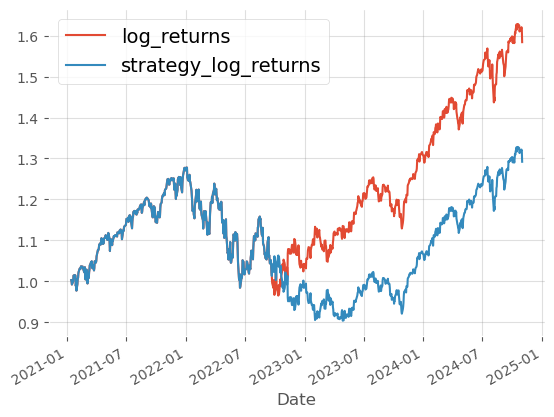

In [205]:
EMA.iloc[int(0.8 * len(EMA)):][['log_returns', 'strategy_log_returns']].cumsum().apply(np.exp).plot()

<a id="macd"></a>
#### <font color="orange"> Part 1.3 - MACD</font>
###### [Back to table of contents](#bookmark)


In [206]:
def MACD_strategy(data, short_window, long_window, signal_window):
    df = pd.DataFrame(index=data.index)

    df["Adj Close"] = data["Adj Close"]

    # Strategy
    df["short_EWMA"] = df["Adj Close"].ewm(span=short_window, min_periods=short_window).mean()
    df["long_EWMA"] = df["Adj Close"].ewm(span=long_window, min_periods=long_window).mean()

    df["MACD"] = df["short_EWMA"]- df["long_EWMA"]
    df["MACD_signal_line"] = df["MACD"].ewm(span=signal_window).mean()

    df["diff"] = df["MACD"] - df["MACD_signal_line"]

    # Position Cross
    df["position_cross"] = (np.sign(df["diff"] * df["diff"].shift(1)) == -1)
    df["position_MACD_direction"] = np.sign(df["MACD"].diff())

    # Bearish & Bullish
    bullish = (df["position_MACD_direction"] > 0) & (df["position_cross"])
    bearish = (df["position_MACD_direction"] < 0) & (df["position_cross"])

    df["trades"] = np.where(bullish, 1, np.nan)
    df["trades"] = np.where(bearish, -1, df["trades"])
    df["Positions"] = df["trades"].ffill()


    # Returns
    df["log_returns"] = np.log(df["Adj Close"] / df["Adj Close"].shift(1))
    df["strategy_log_returns"] = df["Positions"].shift(1) * df["log_returns"]

    return df

In [207]:
# Hyperparameter tuning for MACD
short_windows = range(5, 21, 1)   # Short MACD windows
long_windows = range(20, 201, 1)  # Long MACD windows
signal_windows = range(5, 13, 1)
results = []

for short_window, long_window, signal_window in tqdm(product(short_windows, long_windows, signal_windows), total=len(short_windows) * len(long_windows) * len(signal_windows)):
    if short_window >= long_window:
        continue  # Skip invalid pairs
    strategy_data = MACD_strategy(spy_df, short_window, long_window, signal_window)
    total_return, sharpe_ratio = evaluate_strategy(strategy_data.iloc[:int(0.8 * len(strategy_data))]['strategy_log_returns'])
    results.append((short_window, long_window, signal_window, total_return, sharpe_ratio))

# Convert results to a DataFrame
results_df = pd.DataFrame(results, columns=["Short_Window", "Long_Window", "Signal_Window", "Total_Return", "Sharpe_Ratio"])

# Display the best parameters
best_params = results_df.sort_values("Total_Return", ascending=False).iloc[0]
print("Best Parameters (In-sample):")
print(best_params)



100%|██████████| 23168/23168 [03:04<00:00, 125.54it/s]

Best Parameters (In-sample):
Short_Window      19.000000
Long_Window      167.000000
Signal_Window     12.000000
Total_Return       2.129283
Sharpe_Ratio       0.357551
Name: 21455, dtype: float64


In [208]:
short_MACD = 19
long_MACD = 167
signal_MACD = 12

MACD = MACD_strategy(spy_df, short_window=short_MACD, long_window=long_MACD, signal_window=signal_MACD)
MACD

,Adj Close,short_EWMA,long_EWMA,MACD,MACD_signal_line,diff,position_cross,position_MACD_direction,trades,Positions,log_returns,strategy_log_returns
Date,,,,,,,,,,,,
2005-11-01,83.991142,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
2005-11-02,84.869446,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,0.010403,NaN
2005-11-03,85.231941,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,0.004262,NaN
2005-11-04,85.120407,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,-0.001309,NaN
2005-11-07,85.204071,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,0.000982,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-25,579.039978,577.215704,536.875248,40.340456,39.912817,0.427639,False,-1.0,NaN,1.0,-0.000345,-0.000345
2024-10-28,580.830017,577.577135,537.398519,40.178617,39.953709,0.224907,False,-1.0,NaN,1.0,0.003087,0.003087
2024-10-29,581.770020,577.996424,537.926751,40.069673,39.971550,0.098123,False,-1.0,NaN,1.0,0.001617,0.001617


### Mean Reversion

<a id="rsi"></a>
#### <font color="orange"> Part 1.4 - Relative Strength Index (RSI)</font>
###### [Back to table of contents](#bookmark)


In [209]:
def RSI_strategy(data, period):
    df = data.copy()

    df["Change"] = df["Adj Close"].diff()

    df["Gain"] = df["Change"].apply(lambda x: x if x > 0 else 0)
    df["Loss"] = df["Change"].apply(lambda x: -x if x < 0 else 0)

    df["Avg_Gain"] = df["Gain"].rolling(period).mean()
    df["Avg_Loss"] = df["Loss"].rolling(period).mean()

    for i in range(14,len(df)):
        df.iloc[i,4] = (df.iloc[i-1]["Avg_Gain"]*13+df.iloc[i]["Gain"])/14
        df.iloc[i,5] = (df.iloc[i-1]["Avg_Loss"]*13+df.iloc[i]["Loss"])/14

    df["RS"] = df["Avg_Gain"]/df["Avg_Loss"]
    df["RSI"] = 100 - 100 / (1+df["RS"])
    
    # create position
    df["Positions"] = np.where(((df["RSI"]-70)*(df["RSI"].shift(1)-70)<0)&(df["RSI"]<70), -1, np.nan)
    df["Positions"] = np.where(((df["RSI"]-30)*(df["RSI"].shift(1)-30)<0)&(df["RSI"]>30), 1, df["Positions"])
    df["Positions"] = np.where(((df["RSI"]-50)*(df["RSI"].shift(1)-50)<0), 0, df["Positions"])
    df["Positions"] = df["Positions"].ffill()
    df["Positions"] = df["Positions"].fillna(0)

    # Returns
    df["log_returns"] = np.log(df["Adj Close"] / df["Adj Close"].shift(1))
    df["strategy_log_returns"] = df["Positions"].shift(1) * df["log_returns"]
    
    return df

In [210]:
rsi_period = 14

RSI = RSI_strategy(spy_df, rsi_period)

RSI

,Adj Close,Change,Gain,Loss,Avg_Gain,Avg_Loss,RS,RSI,Positions,log_returns,strategy_log_returns
Date,,,,,,,,,,,
2005-11-01,83.991142,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2005-11-02,84.869446,0.878304,0.878304,0.000000,NaN,NaN,NaN,NaN,0.0,0.010403,0.0
2005-11-03,85.231941,0.362495,0.362495,0.000000,NaN,NaN,NaN,NaN,0.0,0.004262,0.0
2005-11-04,85.120407,-0.111534,0.000000,0.111534,NaN,NaN,NaN,NaN,0.0,-0.001309,-0.0
2005-11-07,85.204071,0.083664,0.083664,0.000000,NaN,NaN,NaN,NaN,0.0,0.000982,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2024-10-25,579.039978,-0.200012,0.000000,0.200012,1.481531,1.124041,1.318039,56.860093,0.0,-0.000345,-0.0
2024-10-28,580.830017,1.790039,1.790039,0.000000,1.503567,1.043753,1.440540,59.025454,0.0,0.003087,0.0
2024-10-29,581.770020,0.940002,0.940002,0.000000,1.463313,0.969199,1.509816,60.156447,0.0,0.001617,0.0


<a id="bb"></a>
#### <font color="orange"> Part 1.5 - Bollinger Bands</font>
###### [Back to table of contents](#bookmark)


In [211]:
# as a assist signal
def BB_strategy(data, period, multiplier):
    df = data.copy()

    df[f"SMA_{period}"] = df["Adj Close"].rolling(period).mean()
    df["Upper_threshold"] = multiplier * df["Adj Close"].rolling(period).std() + df[f"SMA_{period}"]
    df["Lower_threshold"] = -multiplier * df["Adj Close"].rolling(period).std() + df[f"SMA_{period}"]

    distance_upper = df["Adj Close"] - df["Upper_threshold"]
    distance_lower = df["Lower_threshold"] - df["Adj Close"]

    df["Positions"] = np.where(((distance_upper) * (distance_upper.shift(1)) < 0) & (distance_upper > 0), -1, np.nan)
    df["Positions"] = np.where(((distance_lower) * (distance_lower.shift(1)) < 0) & (distance_lower > 0), 1, df["Positions"])
    df["Positions"] = np.where((df["Adj Close"] < df["Upper_threshold"]) & (df["Adj Close"] > df["Lower_threshold"]), 0, df["Positions"])
    df["Positions"] = df["Positions"].ffill()
    df["Positions"] = df["Positions"].fillna(0)
    
    # Returns
    df["log_returns"] = np.log(df["Adj Close"] / df["Adj Close"].shift(1))
    df["strategy_log_returns"] = df["Positions"].shift(1) * df["log_returns"]

    return df

In [212]:
# Hyperparameter tuning for BB
windows = range(10, 101, 5)   # BB windows
multipliers = np.arange(1.5, 3.5, 0.5)  # no. of std deviations
results = []

for window, multiplier in tqdm(product(windows, multipliers), total=len(windows) * len(multipliers)):
    strategy_data = BB_strategy(spy_df, window, multiplier)
    total_return, sharpe_ratio = evaluate_strategy(strategy_data.iloc[:int(0.8 * len(strategy_data))]['strategy_log_returns'])
    results.append((window, multiplier, total_return, sharpe_ratio))

# Convert results to a DataFrame
results_df = pd.DataFrame(results, columns=["BB_Window", "Multiplier", "Total_Return", "Sharpe_Ratio"])

# Display the best parameters
best_params = results_df.sort_values("Total_Return", ascending=False).iloc[0]
print("Best Parameters (In-sample):")
print(best_params)

100%|██████████| 76/76 [00:00<00:00, 119.81it/s]

Best Parameters (In-sample):
BB_Window       15.000000
Multiplier       1.500000
Total_Return     2.414539
Sharpe_Ratio     0.577883
Name: 4, dtype: float64


In [213]:
period_BB = 15  # Typical Bollinger Band period
multiplier_BB = 1.5  # Multiplier for the standard deviation

BB = BB_strategy(spy_df, period_BB, multiplier_BB)


### Machine Learning

In [214]:
## Stats & Models
import statsmodels.api as sm
import statsmodels.tsa.arima.model as stats
from sklearn.linear_model import *
from sklearn.ensemble import *
from sklearn.neighbors import *
from sklearn.tree import *
from sklearn.svm import *
from xgboost import XGBClassifier
## Feature Selection
from sklearn.feature_selection import *
from sklearn.decomposition import PCA

## Performance Metrics
from sklearn.metrics import mean_squared_error, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, KFold

<a id="regression"></a>
#### <font color="orange"> Part 1.6 - Supervised ML (Regression based)</font>
###### [Back to table of contents](#bookmark)

In [215]:
indices = ["^GSPC", "^DJI", "^VIX"]
fx_rates = ["JPY=X", "GBPUSD=X"]
stocks = ["AAPL", "MSFT", "AMZN"]
corr_assets = ["SPY"] + indices + fx_rates + stocks

ml_df = yf.download(tickers=corr_assets)["Adj Close"]
ml_df = ml_df.dropna().copy()

[*********************100%%**********************]  9 of 9 completed


In [216]:
return_period = 5
Y = np.log(ml_df["SPY"]).diff(return_period).shift(-return_period)
X1 = np.log(ml_df[stocks]).diff(return_period)
X2 = np.log(ml_df[fx_rates]).diff(return_period)
X3 = np.log(ml_df[indices]).diff(return_period)
X4 = pd.concat(
    [
        np.log(ml_df[["SPY"]]).diff(i)
        for i in [
            return_period,
            return_period * 3,
            return_period * 6,
            return_period * 12,
        ]
    ],
    axis=1,
)

X4.columns = ["SPY_5D", "SPY_15D", "SPY_30D", "SPY_60D"]

X5 = pd.concat([ml_df[["SPY"]].rolling(i).mean() for i in [21, 63, 252]], axis=1)
X5.columns = ["SPY_21MA", "SPY_63MA", "SPY_252MA"]

X6 = pd.concat([ml_df[["SPY"]].ewm(span=i).mean() for i in [10, 30, 200]], axis=1)
X6.columns = ["SPY_10EMA", "SPY_30EMA", "SPY_200EMA"]

X = pd.concat([X1, X2, X3, X4, X5, X6], axis=1)
data = pd.concat([Y, X], axis=1).dropna().iloc[::return_period, :]

Y = data.loc[ : , Y.name]
X = data.loc[ : , X.columns]

In [217]:
# Train-test Split
validation_size = 0.20

train_size = int(len(X) * (1 - validation_size))

X_train, X_test = (X[0:train_size], X[train_size : len(X)])

Y_train, Y_test = (Y[0:train_size], Y[train_size : len(X)])

In [218]:
# Model Fitting

# Linear and Tree
models = []

models.append(("LR", LinearRegression()))
models.append(("LASSO", Lasso()))
models.append(("EN", ElasticNet()))
models.append(("CART", DecisionTreeRegressor()))
models.append(("KNN", KNeighborsRegressor()))
models.append(("SVR", SVR()))

# Bagging (Boostrap Aggregation)
models.append(("RFR", RandomForestRegressor()))
models.append(("ETR", ExtraTreesRegressor()))

# Boosting
models.append(("GBR", GradientBoostingRegressor()))
models.append(("ABR", AdaBoostRegressor()))

In [219]:
# CV
num_folds = 10
seed = 241001
scoring = "neg_mean_squared_error"

### Initialization of Lists:

names = []
kfold_results = []
train_results = []
test_results = []
result_df = pd.DataFrame()

for name, model in models:
    names.append(name)
    ### Let's run K-fold Cross-Validation
    kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)

    cv_results = -1 * cross_val_score(
        model, X_train, Y_train, cv=kfold, scoring=scoring
    )

    kfold_results.append(cv_results)


    res = model.fit(X_train, Y_train)

    train_result = mean_squared_error(res.predict(X_train), Y_train)
    train_results.append(train_result)

    test_result = mean_squared_error(res.predict(X_test), Y_test)
    test_results.append(test_result)

    predict_df = pd.DataFrame(res.predict(X), index = X.index) # To Predict Full Dataset for backtesting later
    
    result_df.loc[: , name] = predict_df

    # Printing the Results:
    message = "%s: %f %f" % (
        name,
        train_result,
        test_result,
    )
    print(message)

LR: 0.000673 0.000607
LASSO: 0.000716 0.000547
EN: 0.000716 0.000547
CART: 0.000000 0.001541
KNN: 0.000581 0.000612
SVR: 0.000943 0.002655
RFR: 0.000121 0.000693
ETR: 0.000000 0.000660
GBR: 0.000228 0.000579
ABR: 0.000533 0.000747


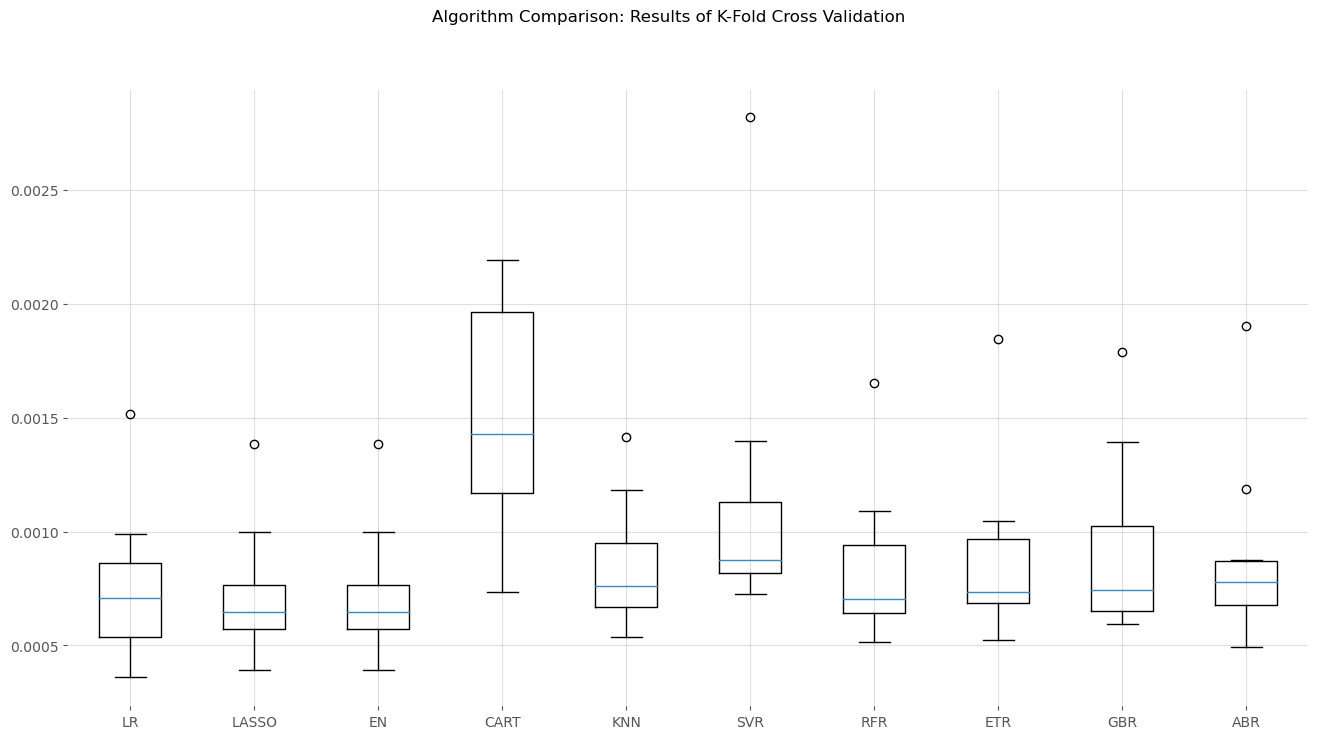

In [220]:
fig = plt.figure(figsize=[16, 8])

fig.suptitle("Algorithm Comparison: Results of K-Fold Cross Validation")

ax = fig.add_subplot(111)

plt.boxplot(kfold_results)

ax.set_xticklabels(names)

plt.show()

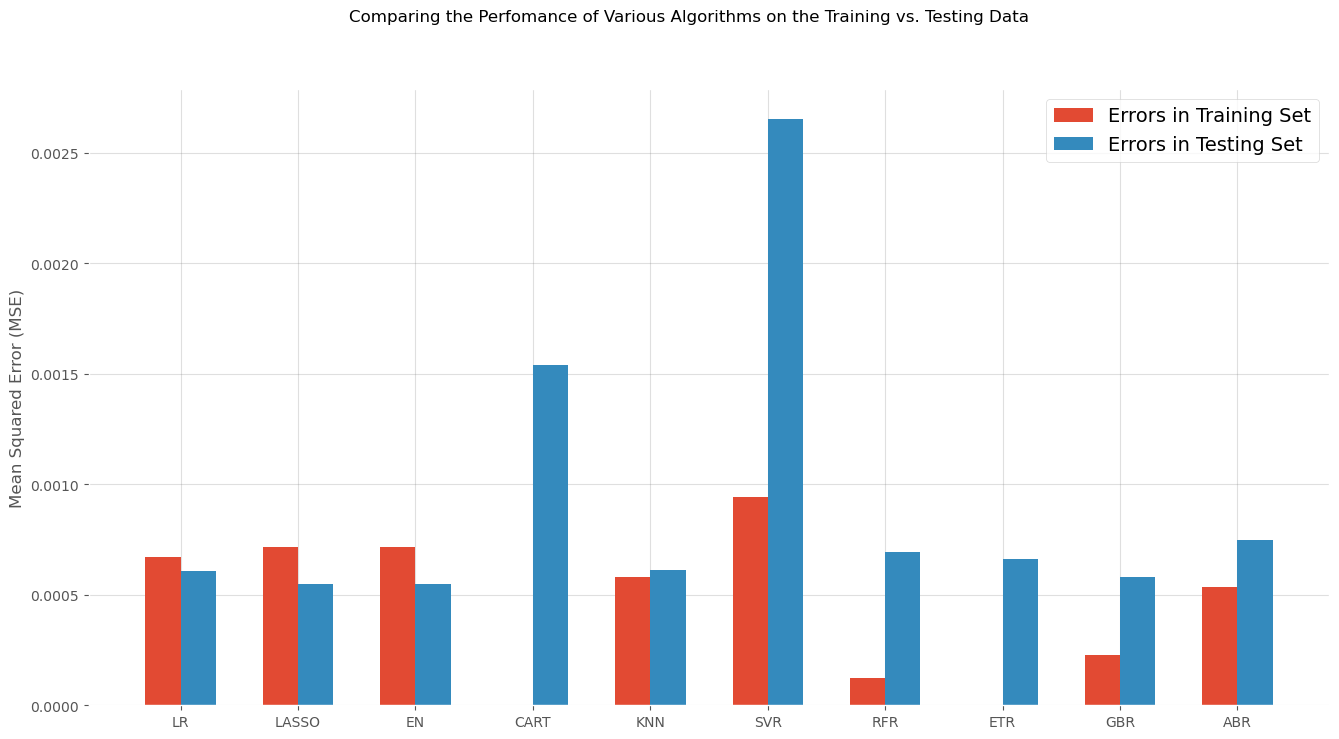

In [221]:
# Plots
## Train-Test results
fig = plt.figure(figsize=[16, 8])
ind = np.arange(len(names))
width = 0.30
fig.suptitle(
    "Comparing the Perfomance of Various Algorithms on the Training vs. Testing Data"
)

ax = fig.add_subplot(111)
(
    plt.bar(
        ind - width / 2,
        train_results,
        width=width,
        label="Errors in Training Set",
    )
)

(plt.bar(ind + width / 2, test_results, width=width, label="Errors in Testing Set"))
plt.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names)
plt.ylabel("Mean Squared Error (MSE)")
plt.show()

In [222]:
# LR has shown to be the model with one of the lower RMSE on the test set and perform consistently on both train and test.
# Use LR for final model.

ML = spy_df.join(result_df).ffill()
ML = ML[["Adj Close", "LR"]].copy()
ML["Positions"] = np.sign(ML["LR"])
ML["log_returns"] = np.log(ML["Adj Close"]/ML["Adj Close"].shift(1))
ML["strategy_log_returns"] = ML["log_returns"] * ML["Positions"].shift(1)
ML.Positions.value_counts()

 1.0    3156
-1.0    1622
Name: Positions, dtype: int64

<a id="pca"></a>
#### <font color=orange> Part 1.7 - Unsupervised ML (PCA based)</font>
###### [Back to table of contents](#bookmark)

In [223]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

top_strategy_df = pd.DataFrame(index=spy_df.index)
top_strategy_df = top_strategy_df.join(SMA[["strategy_log_returns"]])
top_strategy_df = top_strategy_df.rename(columns={"strategy_log_returns": "SMA"})
top_strategy_df = top_strategy_df.join(BB[["strategy_log_returns"]])
top_strategy_df = top_strategy_df.rename(columns={"strategy_log_returns": "BB"})
top_strategy_df = top_strategy_df.join(ML[["strategy_log_returns"]])
top_strategy_df = top_strategy_df.rename(columns={"strategy_log_returns": "ML"})
top_strategy_df = top_strategy_df.apply(lambda x: np.exp(x) - 1)
top_strategy_df2 = top_strategy_df.dropna().copy()

# Standarisation
scaler = StandardScaler().fit(top_strategy_df2)
scaled_top_strat = pd.DataFrame(
    scaler.fit_transform(top_strategy_df2),
    columns=top_strategy_df2.columns,
    index=top_strategy_df2.index,
)

# Model fitting
prop = top_strategy_df.iloc[int(0.8*len(top_strategy_df)):].index[0]

X_Train = scaled_top_strat[:prop]  # First 80% of the data
X_Test = scaled_top_strat[prop:]  # Remaining 20% of the data

X_Train_Raw = top_strategy_df2[:prop]
X_Test_Raw = top_strategy_df2[prop:]

stock_tickers = scaled_top_strat.columns.values

### Model
pca = PCA()
PrincipalComponent = pca.fit(X_Train)  # pca.components_ each row is a PC

### Generating portfolio weights for each PC
# Set the number of principal components to be considered
NumComponents = 3

# Extract the top principal components from the PCA object
# and create a DataFrame with columns named after the original features
topPortfolios = pd.DataFrame(pca.components_[:NumComponents], columns=top_strategy_df2.columns)

# Normalize the weights of the top portfolios such that the weights sum up to 1 for each portfolio
# This is done by dividing each weight by the sum of weights for the respective portfolio
eigen_portfolios = topPortfolios.div(topPortfolios.sum(1), axis=0)

# Rename the index of the eigen_portfolios DataFrame for better readability
eigen_portfolios.index = [f"Portfolio {i}" for i in range(NumComponents)]

def PCWeights():
    weights = pd.DataFrame()
    for i in range(len(pca.components_)):
        weights["weights_{}".format(i)] = pca.components_[i] / sum(pca.components_[i])
    weights = weights.values.T
    return weights  # Team, be careful with indentation

weights= PCWeights()

### Finding Best Portfolio
def calculate_sharpe_ratio(ts_returns, periods_per_year=252):
    n_years = ts_returns.shape[0] / periods_per_year
    annualized_return = np.power(np.prod(1 + ts_returns), (1 / n_years)) - 1
    annualized_vol = ts_returns.std() * np.sqrt(periods_per_year)
    annualized_sharpe = annualized_return / annualized_vol
    return annualized_return, annualized_vol, annualized_sharpe

def valid_backtest_PCA_porfolios(eigen):
    eigen_prtfi = pd.DataFrame(data={"weights": eigen.squeeze()}, index=stock_tickers)

    # Let's directly compute the dot product without sorting
    eigen_prtfi_returns = np.dot(X_Test_Raw, eigen)
    eigen_portfolio_returns = pd.Series(
        eigen_prtfi_returns.squeeze(), index=X_Test_Raw.index
    )
    returns, vol, sharpe = calculate_sharpe_ratio(eigen_portfolio_returns)
    print(
        "Our PCA-based Portfolio:\nReturn = %.2f%%\nVolatility = %.2f%%\nSharpe = %.2f"
        % (returns * 100, vol * 100, sharpe)
    )

    # Compared with what? Equal-weightage Portfolio
    equal_weight_return = (X_Test_Raw * (1 / len(pca.components_))).sum(axis=1)

    df_plot = pd.DataFrame(
        {
            "ML Portfolio Return": eigen_portfolio_returns,
            "Equal Weight Index": equal_weight_return,
        },
        index=X_Test.index,
    )

    np.cumprod(df_plot + 1).plot(
        title="Returns of the equal weighted index vs. Eigen-Portfolio",
        figsize=[16, 8],
    )

    plt.show()

Our PCA-based Portfolio:
Return = 9.23%
Volatility = 7.40%
Sharpe = 1.25


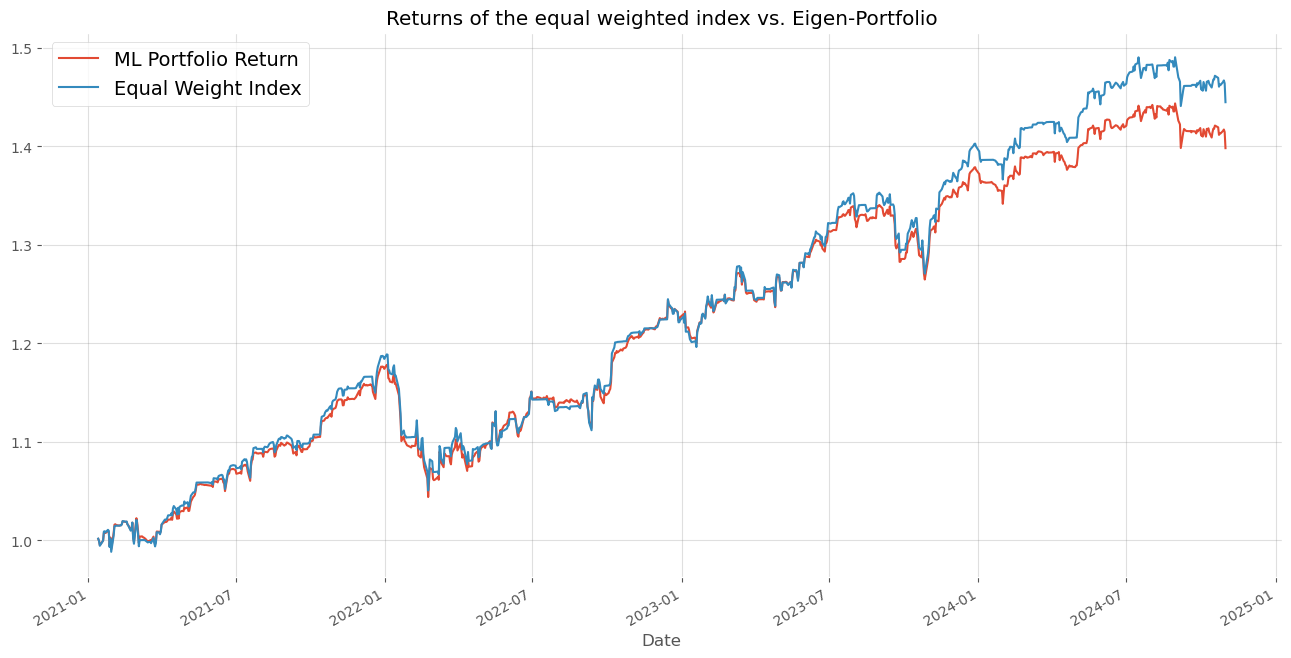

Our PCA-based Portfolio:
Return = -44.84%
Volatility = 100.41%
Sharpe = -0.45


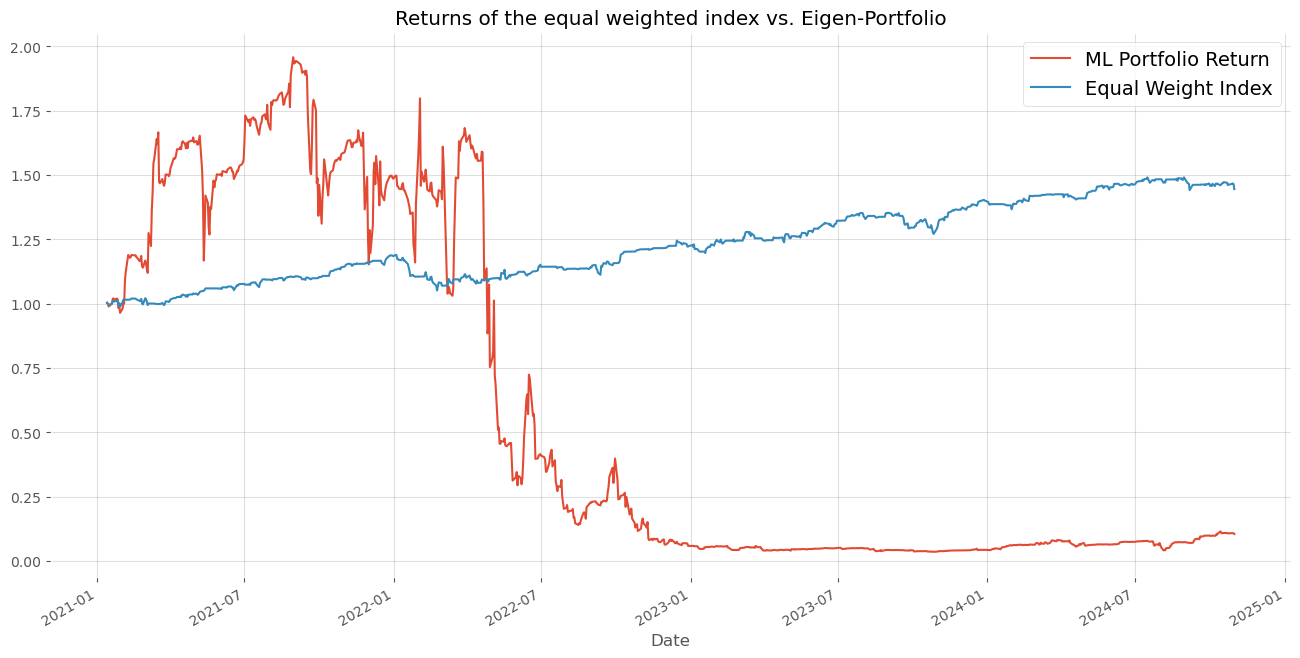

Our PCA-based Portfolio:
Return = 62.03%
Volatility = 49.22%
Sharpe = 1.26


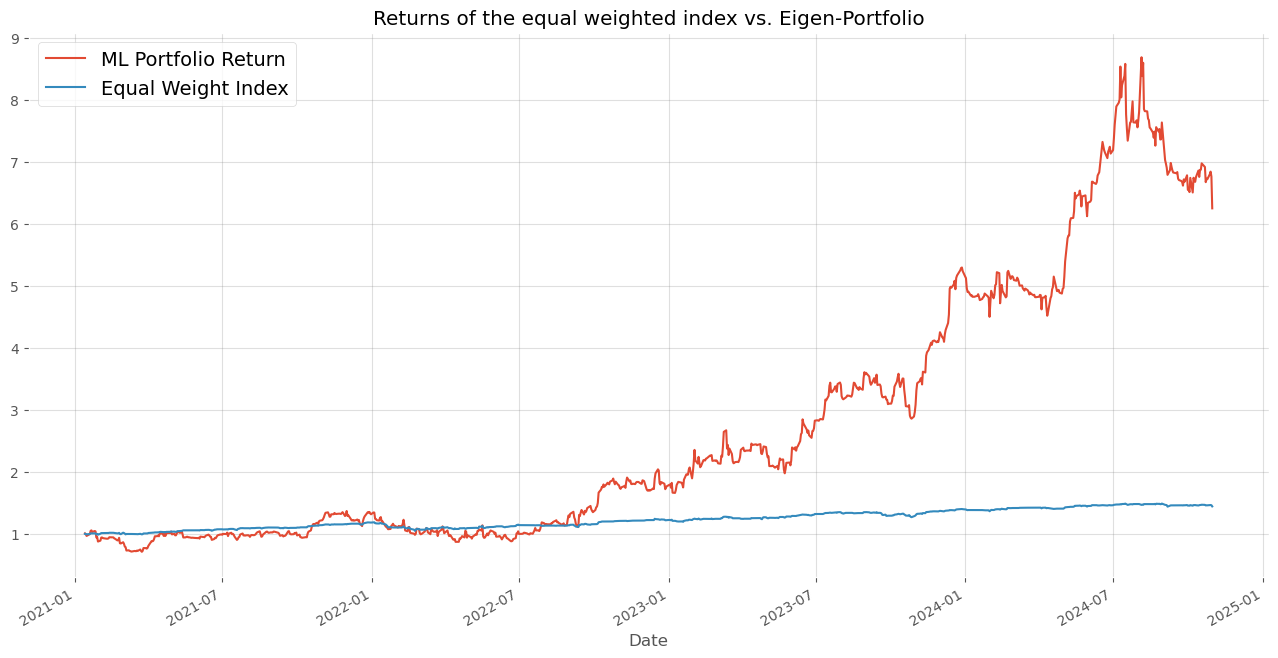

In [224]:
for i in range(NumComponents):
    valid_backtest_PCA_porfolios(weights[i])

In [225]:
# Portfolio 3 showed the best risk-adjusted returns with the highest sharpe ratio
# Weights will be used to allocate capital
weights[2]

array([ 1.458, -2.864,  2.406])

In [226]:
pca_capital_allocation = weights[2]/sum(abs(weights[2])) * 100000

In [227]:
pca_capital_allocation

array([ 21664.862, -42568.141,  35766.997])

In [228]:
# For Full Data
pca_df = ((1+ top_strategy_df).cumprod() - 1) * pca_capital_allocation
pca_df = pca_df.join(spy_df)

pca_df["Portfolio_value"] = 100000 + pca_df.apply(sum, axis=1)
pca_df["log_returns"] = np.log(pca_df["Adj Close"]/pca_df["Adj Close"].shift(1))
pca_df["strategy_log_returns"] = np.log(pca_df["Portfolio_value"]/pca_df["Portfolio_value"].shift(1))

pca_df["cum_returns"] = pca_df["log_returns"].cumsum().apply(np.exp)
pca_df["strategy_cum_returns"] = pca_df["strategy_log_returns"].cumsum().apply(np.exp)

pca_df['cum_max'] = pca_df['cum_returns'].cummax()
pca_df['strategy_cum_max'] = pca_df['strategy_cum_returns'].cummax()

pca_df['Drawdown'] = pca_df['strategy_cum_returns'] / pca_df['strategy_cum_max'] - 1

# For Test Data
pca_df_test = top_strategy_df.iloc[int(0.8*len(top_strategy_df)):].copy()
pca_df_test = ((1+ pca_df_test).cumprod() - 1) * pca_capital_allocation
pca_df_test = pca_df_test.join(spy_df)

pca_df_test["Portfolio_value"] = 100000 + pca_df_test.apply(sum, axis=1)
pca_df_test["log_returns"] = np.log(pca_df_test["Adj Close"]/pca_df_test["Adj Close"].shift(1))
pca_df_test["strategy_log_returns"] = np.log(pca_df_test["Portfolio_value"]/pca_df_test["Portfolio_value"].shift(1))

## Fill in NaN for first row, starting capital is $100,000
pca_df_test["log_returns"].iloc[0] = np.log(spy_df["Adj Close"]/spy_df["Adj Close"].shift(1)).loc[pca_df_test.index[0]]
pca_df_test["strategy_log_returns"].iloc[0] = np.log(pca_df_test["Portfolio_value"].iloc[0]/100000)

pca_df_test["cum_returns"] = pca_df_test["log_returns"].cumsum().apply(np.exp)
pca_df_test["strategy_cum_returns"] = pca_df_test["strategy_log_returns"].cumsum().apply(np.exp)

pca_df_test['cum_max'] = pca_df_test['cum_returns'].cummax()
pca_df_test['strategy_cum_max'] = pca_df_test['strategy_cum_returns'].cummax()

pca_df_test['Drawdown'] = pca_df_test['strategy_cum_returns'] / pca_df_test['strategy_cum_max'] - 1

<a id="part2"></a>
### Part 2 (7 points)
Second, you should backtest the above trading strategies and come up with accompanying data visualization and evidentiary numerical values (i.e., `Sharpe Ratio`, `compound annual growth rate`, `maximum drawdown`, and `how much is left on your account`) that allow you to compare if and which of your strategies beat the baseline performance of S&P 500, and by how much.
###### [Back to table of contents](#bookmark)



In [229]:
# This class provides functions for strategy backtesting and 
# performance evaluation on the partial data as well as
# on the entire data set

# The backtesting will be done on latest 20% data and 
# the strategy performance evaluation will be done on
# the entire data set

class Backtester:
    def __init__(self, df, strategy_name='Abstract Strategy'):
        self.full_df = df.copy()
        self.df = None

        self.strategy_name = strategy_name
        self.starting_capital = 100000
        self.fig_size = (15, 6)
    
    def get_strategy_name(self):
        return self.strategy_name

    def generate_signals(self):
        self.df['Signal'] = self.df['Positions'].diff()

    def calc_sharpe_ratio(self):
        self.df['Log_Return'] = np.log(self.df['Adj Close']).diff().fillna(0)
        self.df['Strategy_Log_Ret'] = self.df['Log_Return'] \
                                    * self.df['Positions'].shift(1).fillna(0)
        
        self.df["Simple_Return"] = self.df["Log_Return"].apply(np.exp) - 1
        self.df["Strategy_Simple_Ret"] = self.df["Strategy_Log_Ret"].apply(np.exp) - 1

        sharpe_ratio = np.mean(self.df["Strategy_Simple_Ret"]) / np.std(self.df["Strategy_Simple_Ret"])\
                        * np.sqrt(252)
                        
        return sharpe_ratio
        
    def calc_cagr(self):
        self.df["Cum_Return"] = self.df["Log_Return"].cumsum().apply(np.exp)
        self.df["Strategy_Cum_Ret"] = self.df["Strategy_Log_Ret"].cumsum().apply(np.exp)
        self.df["Portfolio_Value"] = self.df["Strategy_Cum_Ret"] * self.starting_capital

        initial_portfolio_value = self.df["Portfolio_Value"].iloc[0]
        final_portfolio_value = self.df["Portfolio_Value"].iloc[-1]
        num_days = (self.df.index[-1] - self.df.index[0]).days
        return (final_portfolio_value / initial_portfolio_value) ** (365.0 / num_days) - 1
    
    def get_final_portfolio_value(self):
        return self.df["Portfolio_Value"].iloc[-1]
        
    def get_cum_portfolio_ret(self):
        return self.get_final_portfolio_value() / self.starting_capital - 1

    def calc_max_drawdown(self):
        self.df['Cum_Max'] = self.df['Cum_Return'].cummax()
        self.df['Strategy_Cum_Max'] = self.df['Strategy_Cum_Ret'].cummax()

        # Calculate the drawdown: (Current Value - Cumulative Max) / Cumulative Max
        self.df['Drawdown'] = self.df['Strategy_Cum_Ret'] / self.df['Strategy_Cum_Max'] - 1

        # Max Drawdown
        max_drawdown = self.df['Drawdown'].min()

        # Max Drawdown Day
        max_drawdown_day = self.df['Drawdown'].idxmin().date()
        #print(f'Max Drawdown Day: {max_drawdown_day}')
        
        return -max_drawdown

    # Plot returns and drawdown
    def plot_cumulative_return(self):
        plt.figure(figsize=self.fig_size)
        plt.plot(self.df.index, self.df['Cum_Return'], label='Market_Cum_Return', color="blue", alpha=0.75, lw=1)
        plt.plot(self.df.index, self.df['Cum_Max'], label='Market_Cum_Max', color="red", alpha=0.75, lw=0.5)

        plt.plot(self.df.index, self.df['Strategy_Cum_Ret'], label='Strategy_Cum_Ret', color="green", alpha=0.75, lw=1)
        plt.plot(self.df.index, self.df['Strategy_Cum_Max'], label='Strategy_Cum_Max', color="purple", alpha=0.75, lw=0.5)

        plt.legend()
        plt.title(self.get_strategy_name() + " Returns")
        plt.tight_layout()
        plt.show()

    def plot_drawdown(self):
        plt.figure(figsize=self.fig_size)
        plt.axhline(0, color='red', alpha=0.75, lw=0.5)
        plt.plot(self.df.index, self.df['Drawdown'], label='Drawdown', color="magenta", alpha=0.75, lw=1)

        plt.legend()
        plt.title(self.get_strategy_name() + " Drawdown")
        plt.tight_layout()
        plt.show()
        
    def apply_strategy(self):
        if self.df is None:
            raise ValueError('Please set the data to run strategy on')

        print(f'Running `{self.get_strategy_name()}` Strategy on period '\
                + f'{self.df.index[0].date()} to {self.df.index[-1].date()}')
        
        self.generate_signals()
        print(f'Sharpe Ratio: {self.calc_sharpe_ratio():.2f}')
        print(f'Compound Annual Growth Rate: {self.calc_cagr():.2%}')
        print(f'Max Drawdown: {self.calc_max_drawdown():.2%}')
        print(f'Money Left in Account: {self.get_final_portfolio_value():,.2f}')
        print(f'Cumulative Portfolio Return: {self.get_cum_portfolio_ret():,.2%}')
        #print(self.df.Signal.value_counts())
        
        #self.plot_strategy()
        self.plot_cumulative_return()
        self.plot_drawdown()
        
    def run_backtesting(self):
        # run back test on only latest 20% of data
        total_row_count = len(self.full_df)
        test_row_count = int(total_row_count * 0.2)
        self.df = self.full_df.iloc[-test_row_count:].copy()
        self.apply_strategy()
        
    def evaluate_performance(self):
        # evaluate performance on entire data set
        self.df = self.full_df.copy()
        self.apply_strategy()

Running `Simple Moving Average Crossover` Strategy on period 2005-11-01 to 2024-10-31
Sharpe Ratio: 0.69
Compound Annual Growth Rate: 12.06%
Max Drawdown: 33.72%
Money Left in Account: 871,398.89
Cumulative Portfolio Return: 771.40%


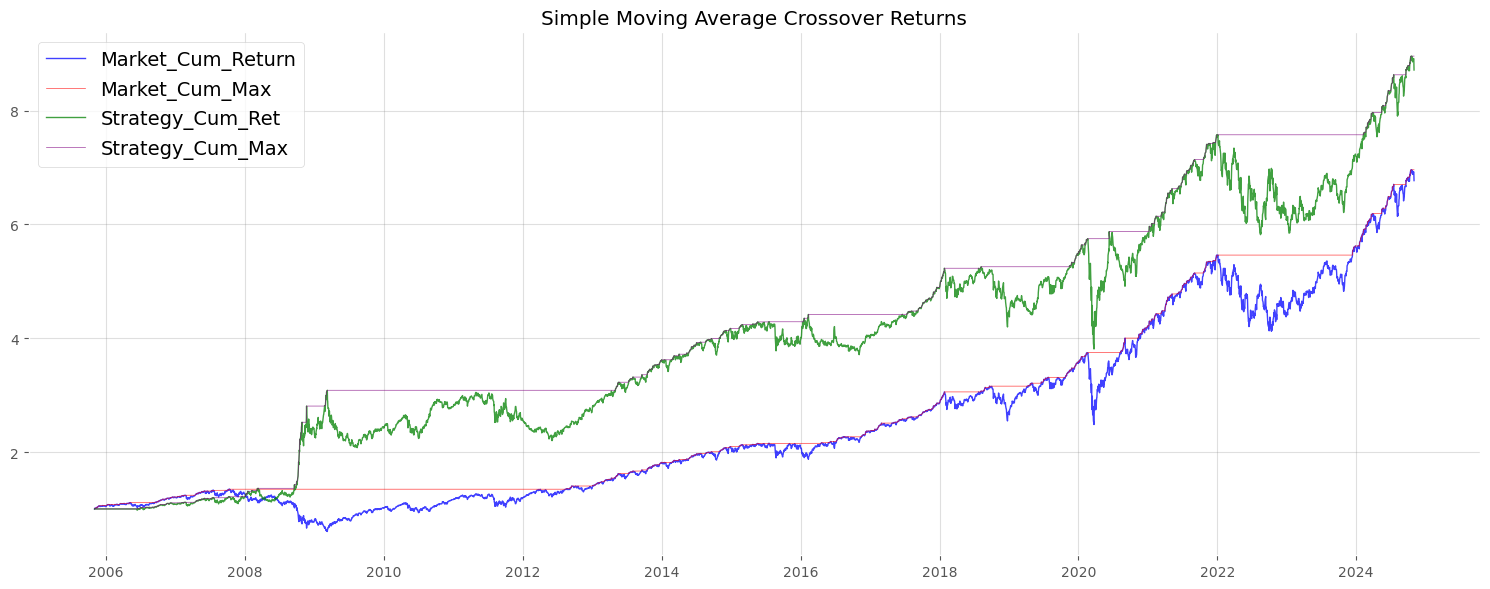

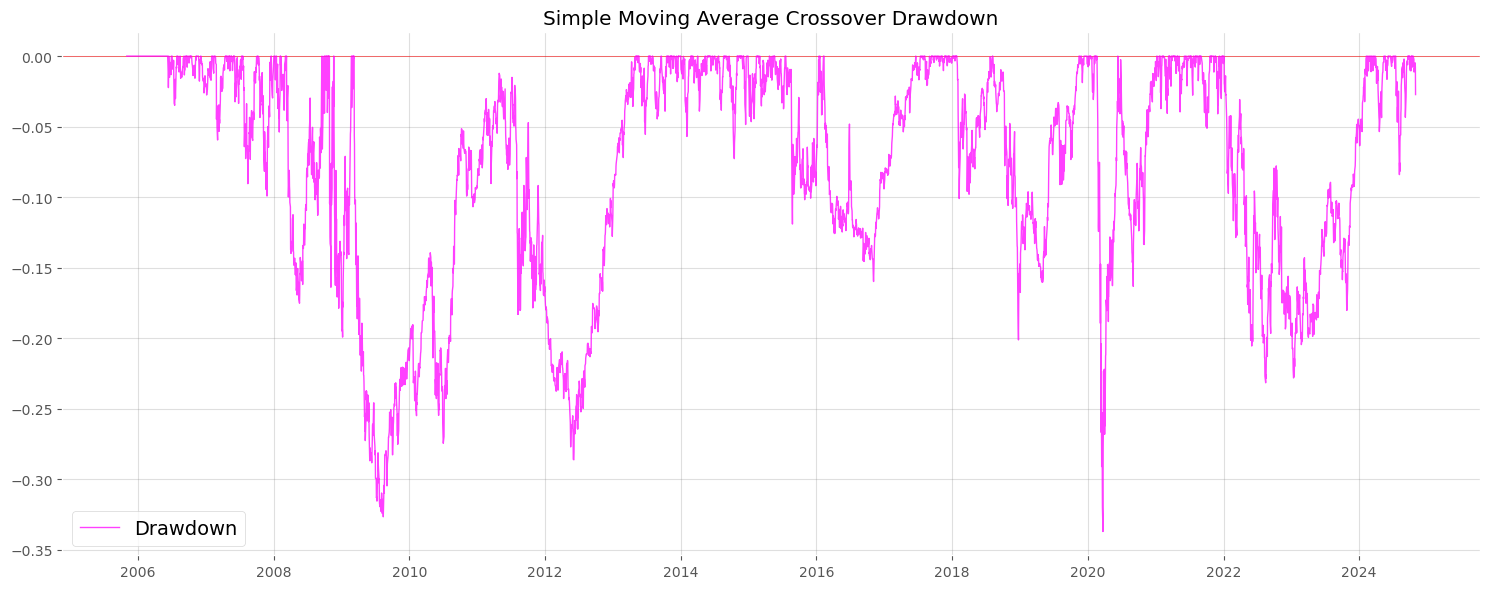

In [230]:
result_df = SMA_strategy(spy_df, short_window=short_SMA, long_window=long_SMA)
backtester = Backtester(result_df, strategy_name="Simple Moving Average Crossover")
backtester.evaluate_performance()

<a id="performance"></a>
#### <font color = orange> Part 2.1 Strategy Performance Evaluation</font>
###### [Back to table of contents](#bookmark)

Running `Simple Moving Average Crossover` Strategy on period 2005-11-01 to 2024-10-31
Sharpe Ratio: 0.69
Compound Annual Growth Rate: 12.06%
Max Drawdown: 33.72%
Money Left in Account: 871,398.89
Cumulative Portfolio Return: 771.40%


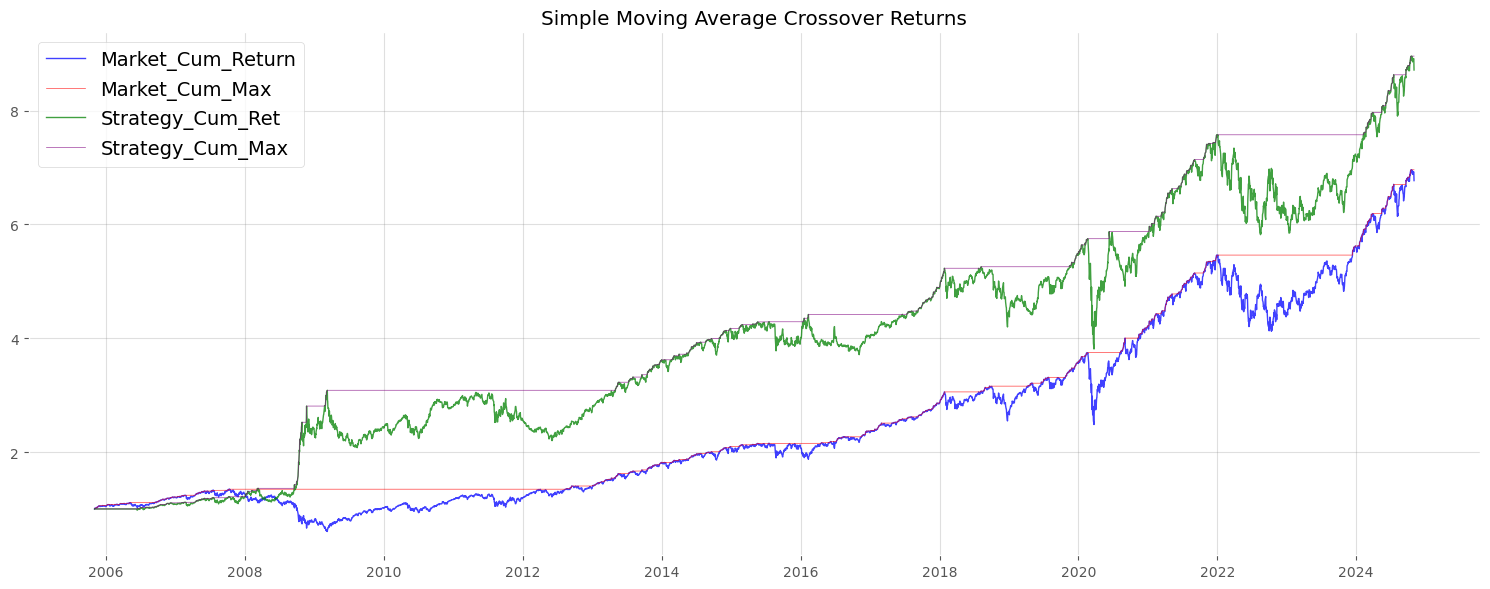

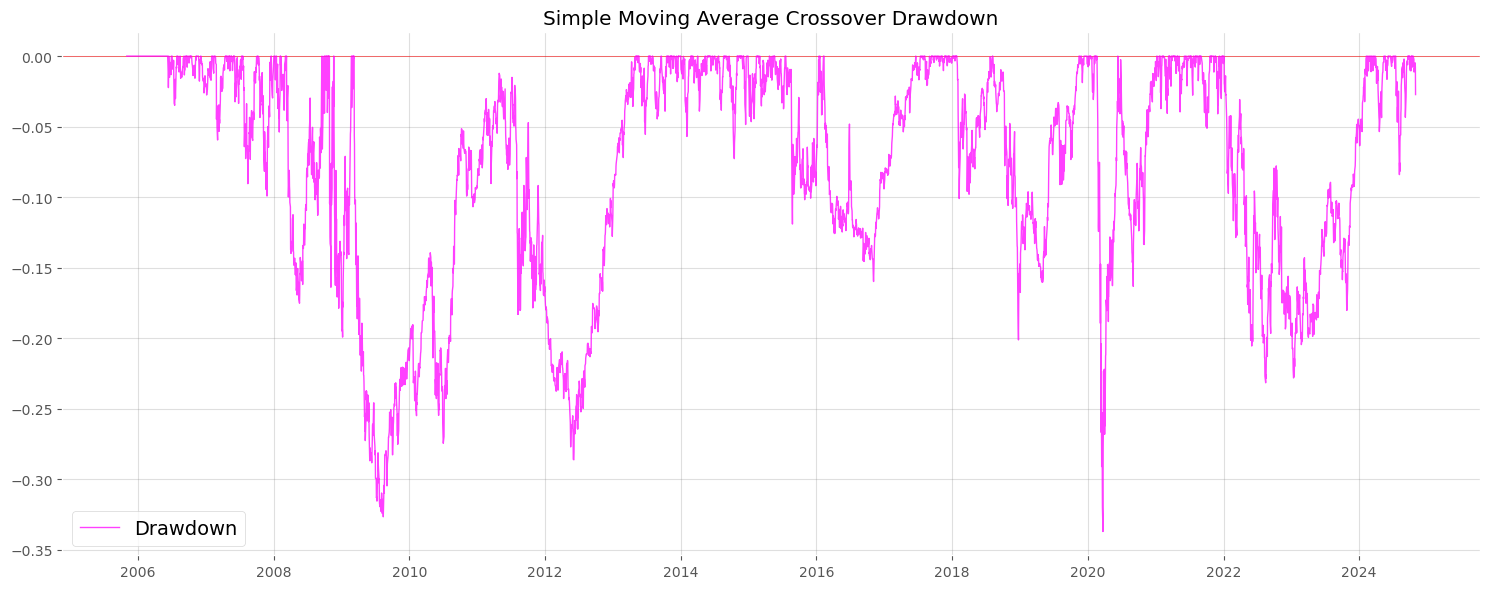

In [231]:
result_df = SMA_strategy(spy_df, short_window=short_SMA, long_window=long_SMA)
backtester = Backtester(result_df, strategy_name="Simple Moving Average Crossover")
backtester.evaluate_performance()

Running `Exponential Moving Average Crossover` Strategy on period 2005-11-01 to 2024-10-31
Sharpe Ratio: 0.65
Compound Annual Growth Rate: 11.29%
Max Drawdown: 42.85%
Money Left in Account: 764,440.96
Cumulative Portfolio Return: 664.44%


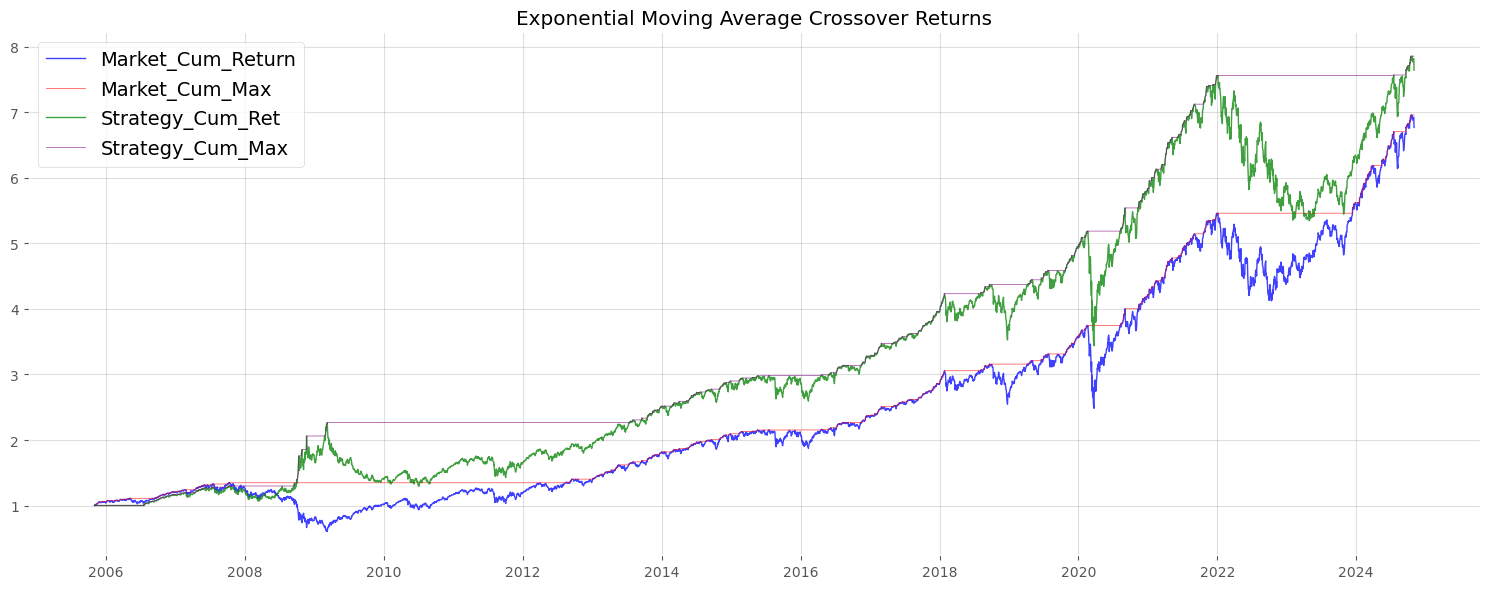

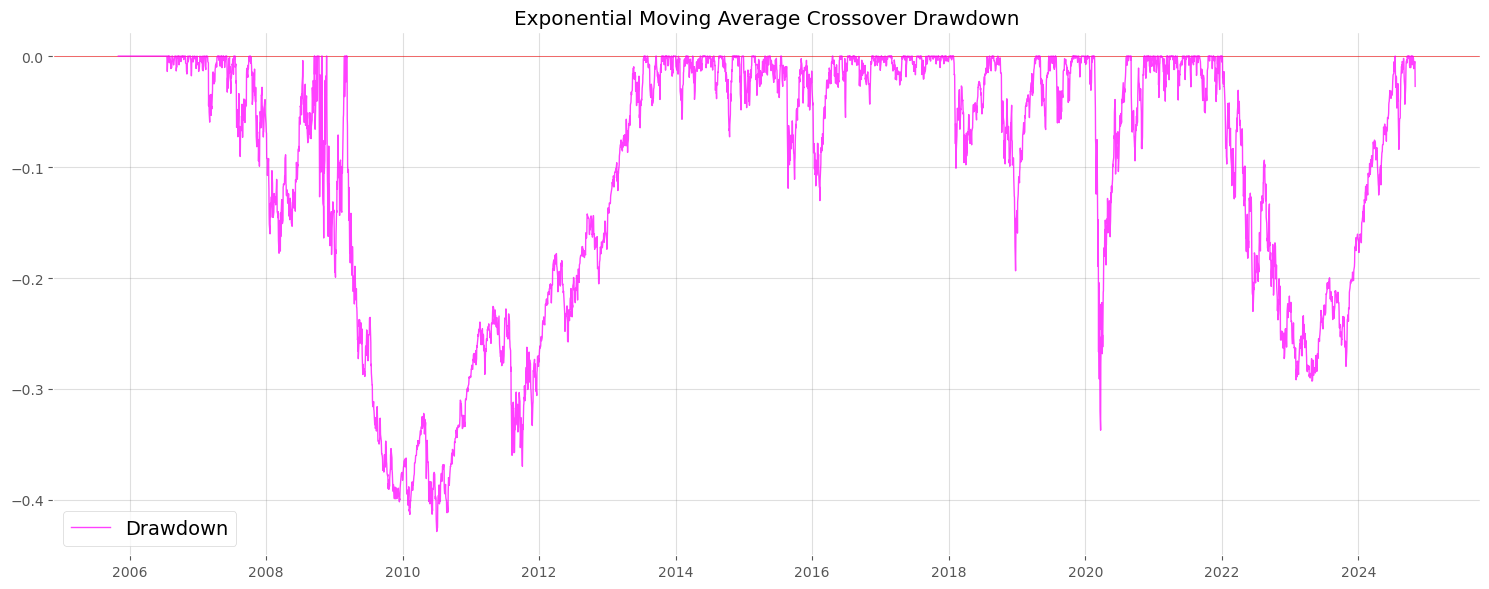

In [232]:
result_df = EMA_strategy(spy_df, short_window=short_EMA, long_window=long_EMA)
backtester = Backtester(result_df, strategy_name="Exponential Moving Average Crossover")
backtester.evaluate_performance()

Running `MACD` Strategy on period 2005-11-01 to 2024-10-31
Sharpe Ratio: 0.32
Compound Annual Growth Rate: 4.36%
Max Drawdown: 37.03%
Money Left in Account: 225,254.30
Cumulative Portfolio Return: 125.25%


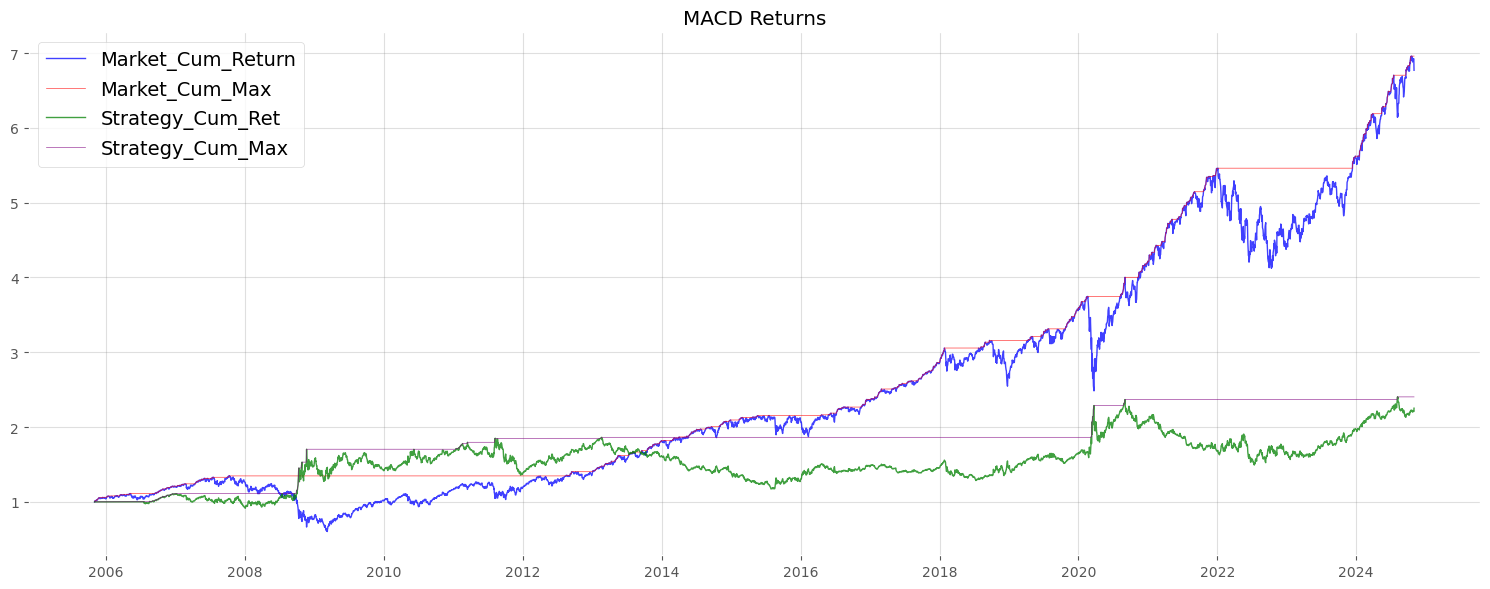

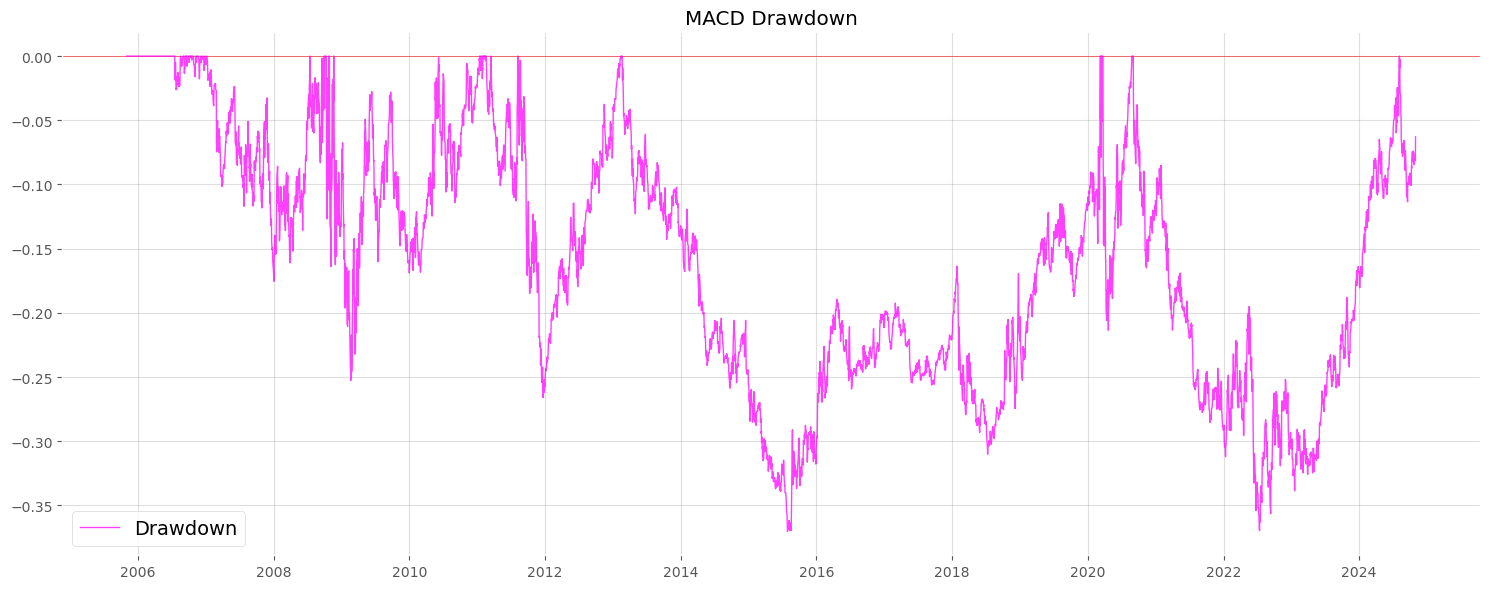

In [233]:
result_df = MACD_strategy(spy_df, short_window=short_MACD, long_window=long_MACD, signal_window=signal_MACD)
backtester = Backtester(result_df, strategy_name="MACD")
backtester.evaluate_performance()

Running `Relative Strength Index` Strategy on period 2005-11-01 to 2024-10-31
Sharpe Ratio: 0.07
Compound Annual Growth Rate: 0.21%
Max Drawdown: 39.88%
Money Left in Account: 104,140.25
Cumulative Portfolio Return: 4.14%


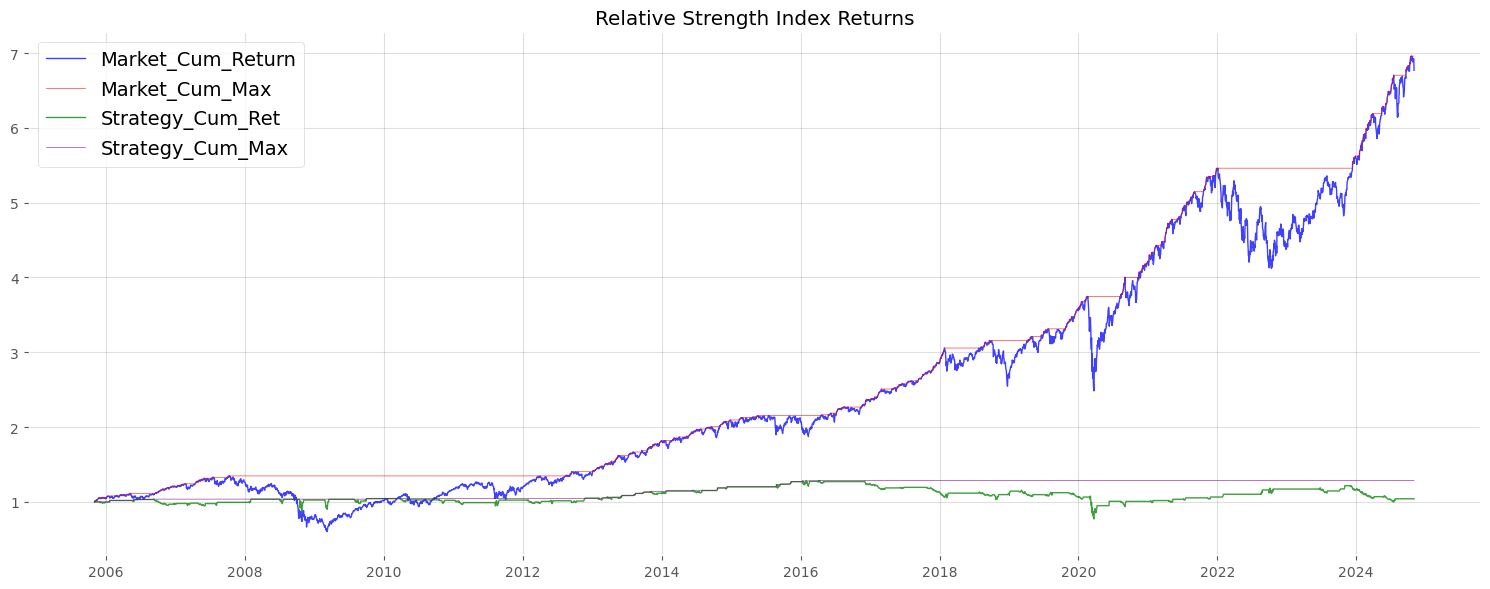

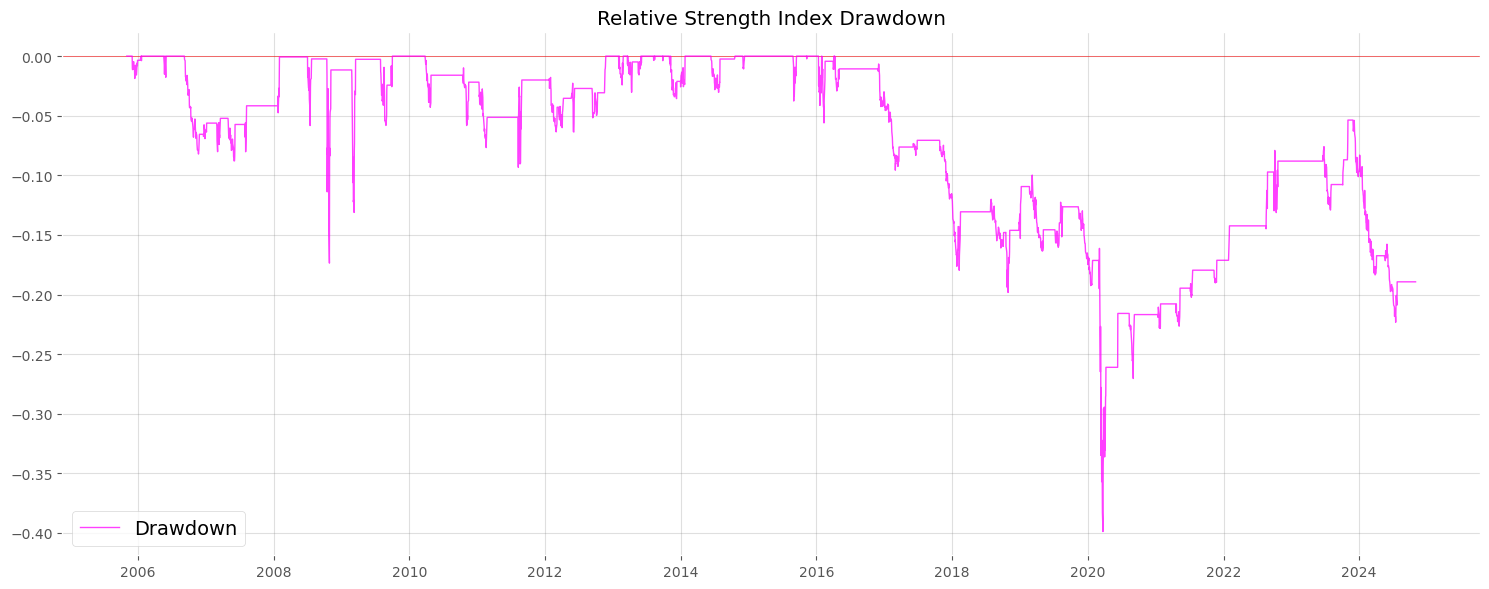

In [234]:
rsi_period = 14
result_df = RSI_strategy(spy_df, rsi_period)
backtester = Backtester(result_df, strategy_name="Relative Strength Index")
backtester.evaluate_performance()

Running `Bollinger Bands` Strategy on period 2005-11-01 to 2024-10-31
Sharpe Ratio: 0.49
Compound Annual Growth Rate: 4.71%
Max Drawdown: 20.88%
Money Left in Account: 240,083.40
Cumulative Portfolio Return: 140.08%


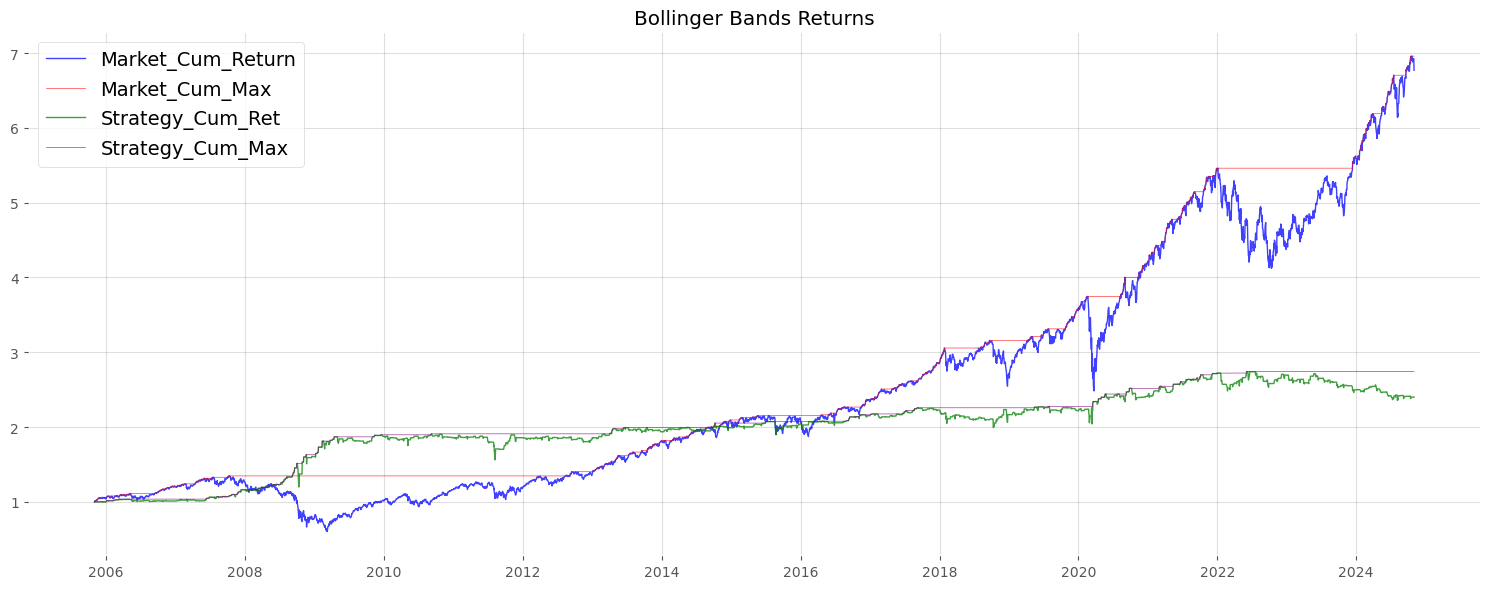

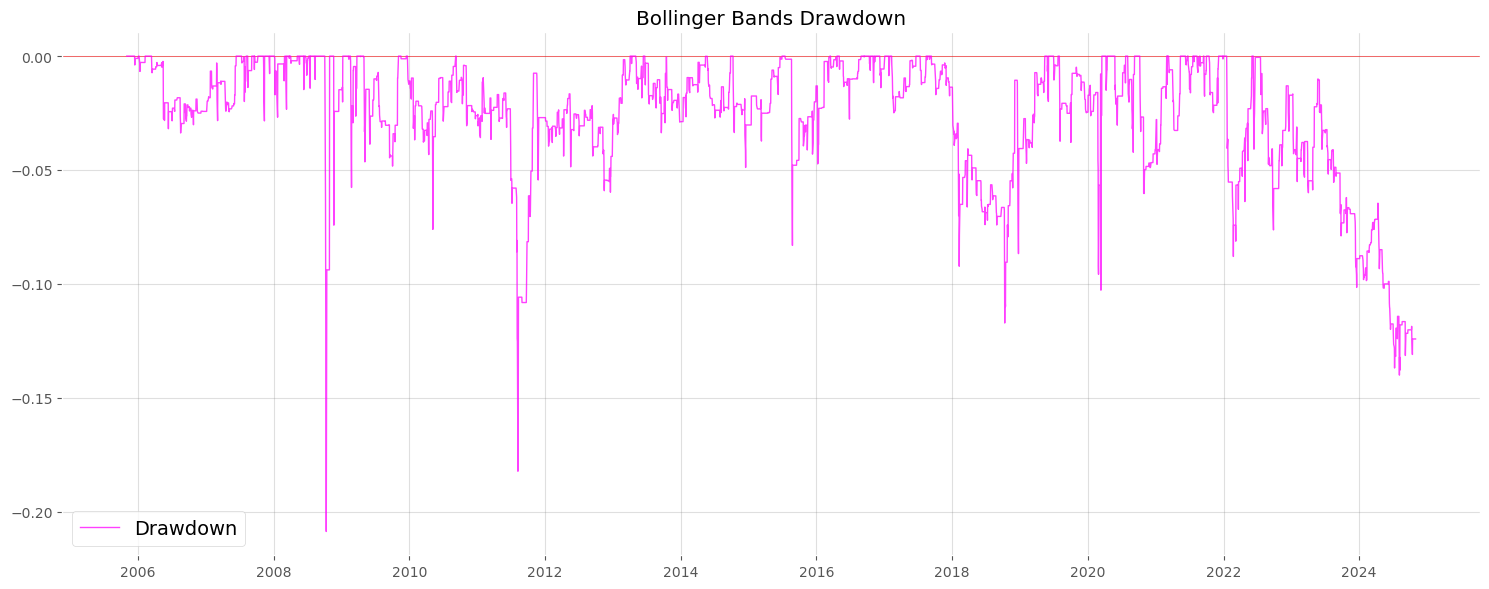

In [235]:
period_BB = 15  # Typical Bollinger Band period
multiplier_BB = 1.5  # Multiplier for the standard deviation
result_df = BB_strategy(spy_df, period_BB, multiplier_BB)
backtester = Backtester(result_df, strategy_name="Bollinger Bands")
backtester.evaluate_performance()

Running `Linear Regression` Strategy on period 2005-11-01 to 2024-10-31
Sharpe Ratio: 0.89
Compound Annual Growth Rate: 16.66%
Max Drawdown: 37.84%
Money Left in Account: 1,870,288.80
Cumulative Portfolio Return: 1,770.29%


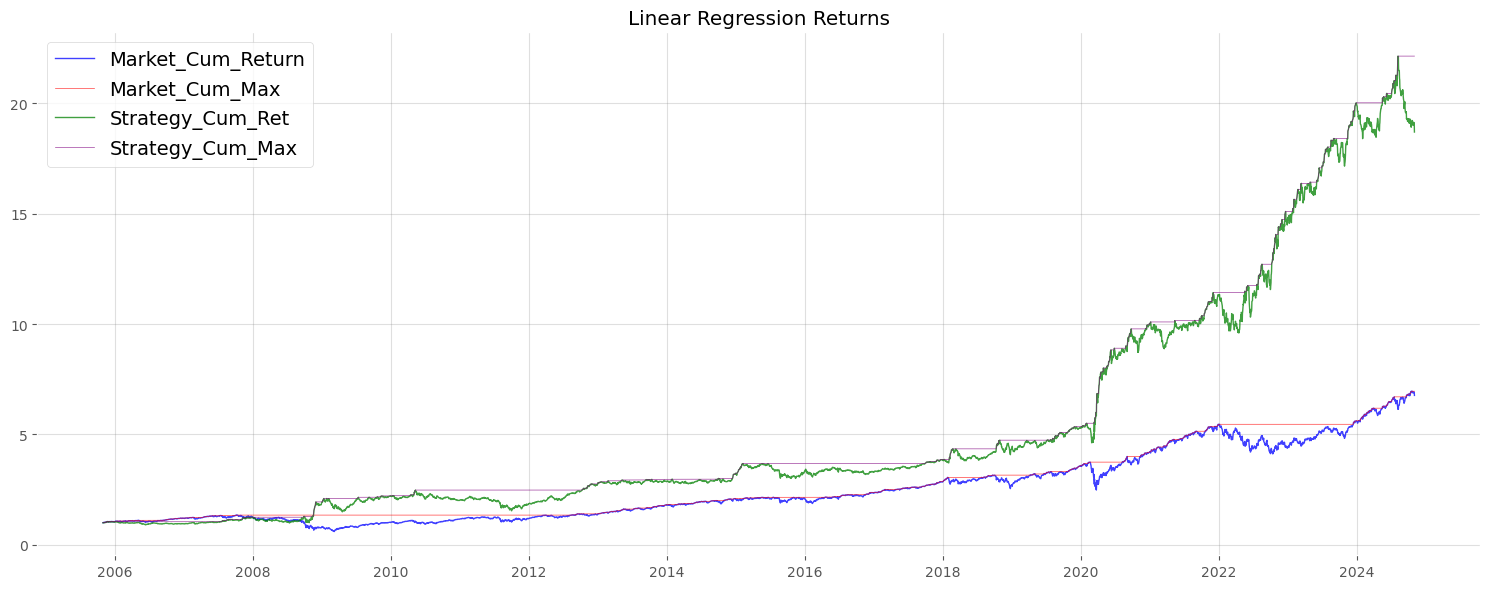

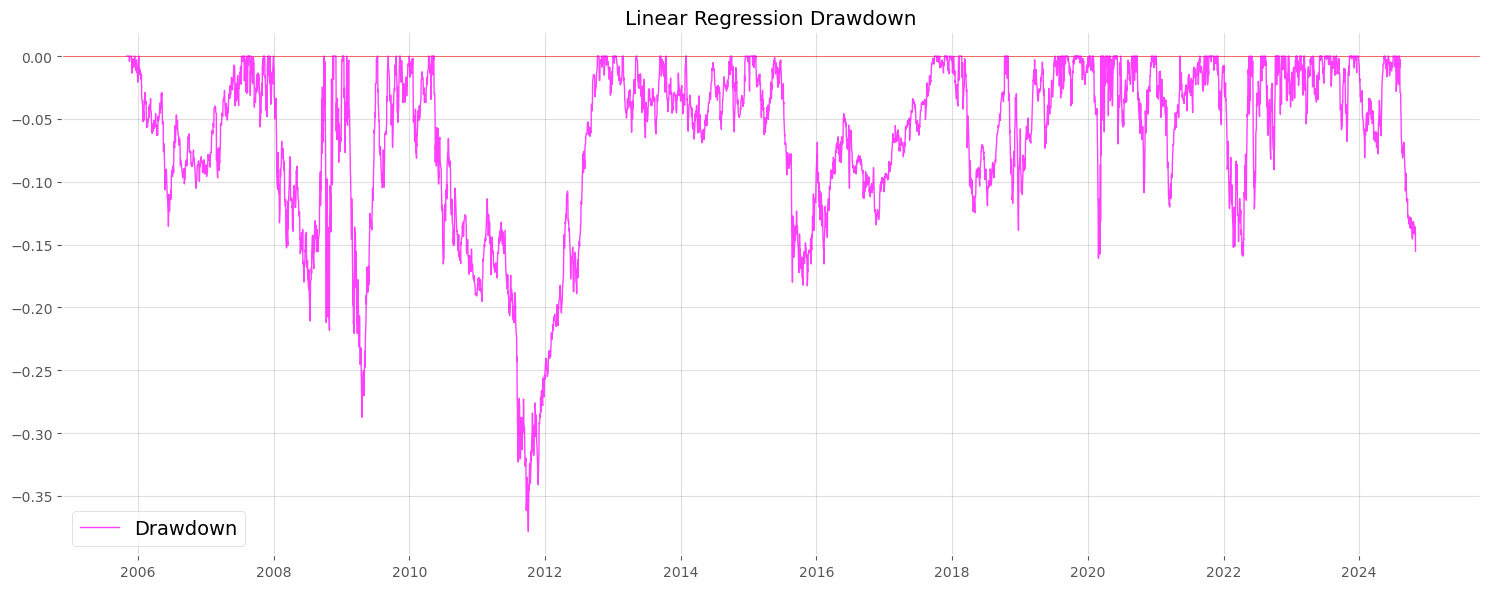

In [236]:
backtester = Backtester(ML, strategy_name="Linear Regression")
backtester.evaluate_performance()

Running `PCA` Strategy on period 2005-11-01 to 2024-10-31
Sharpe Ratio: 0.93
Compound Annual Growth Rate: 11.85%
Max Drawdown: 21.73%
Money Left in Account: 841,239.39
Cumulative Portfolio Return: 741.24%


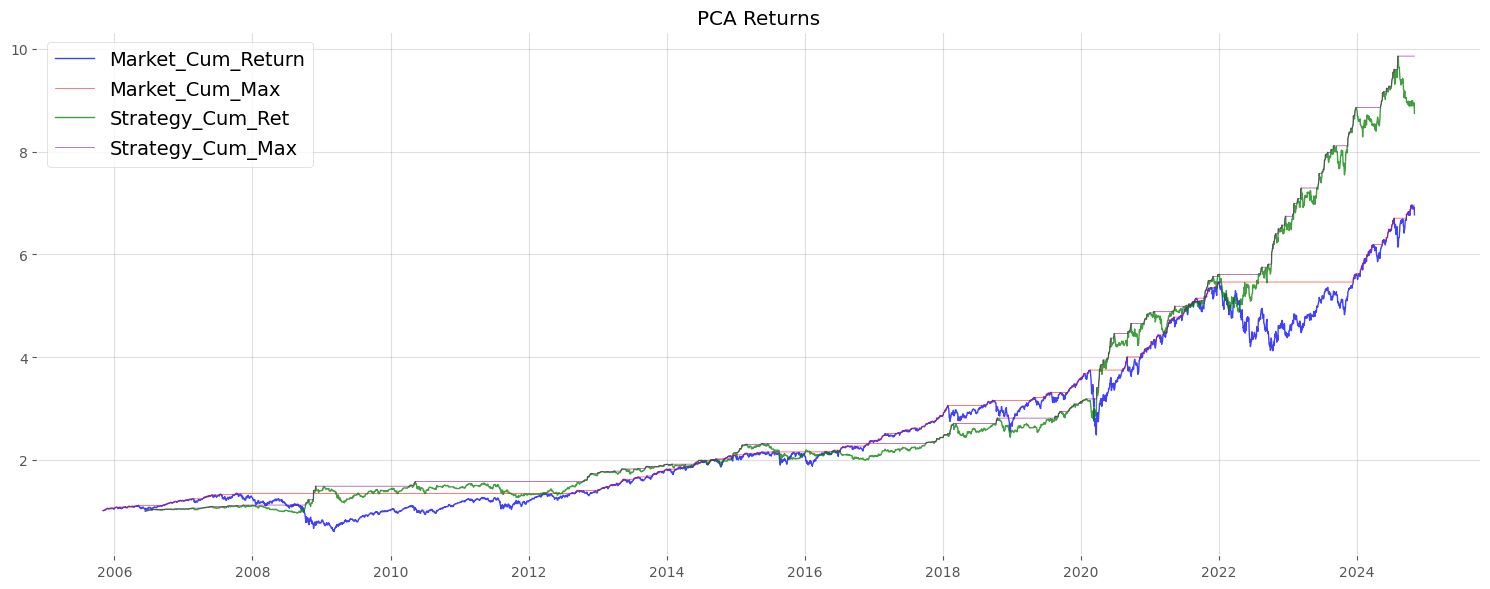

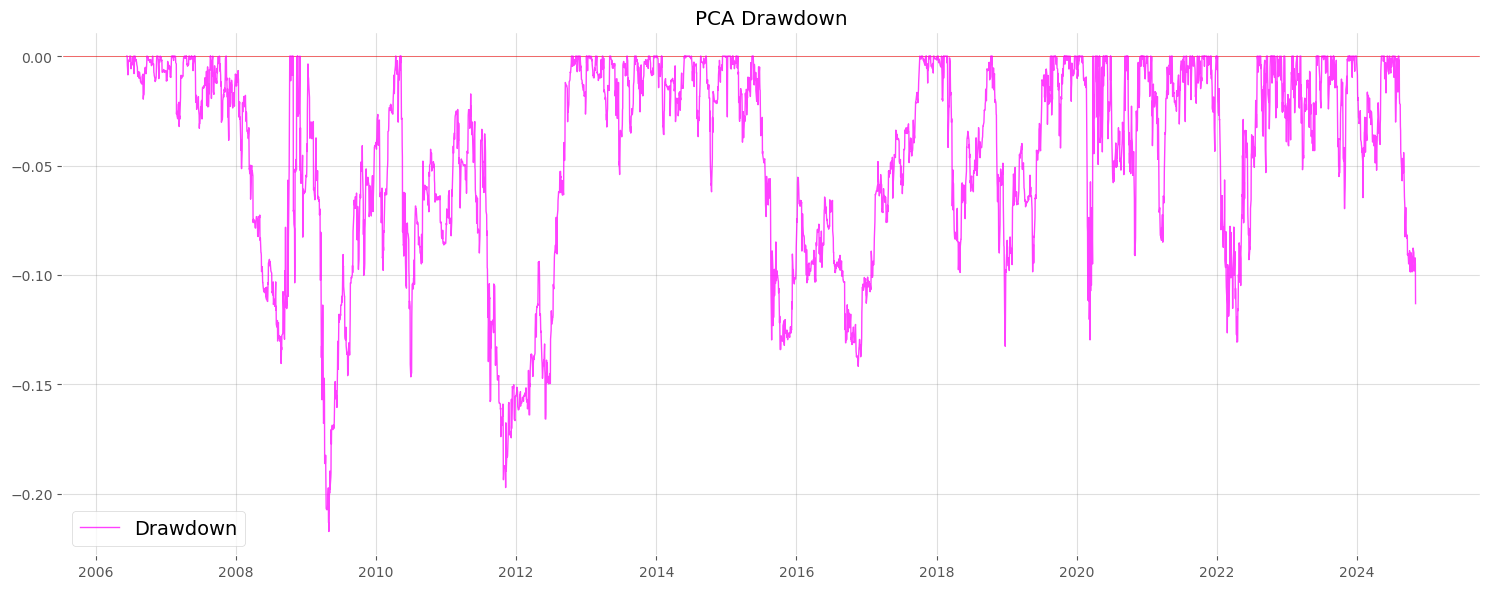

In [237]:
# PCA
pca_simple_ret = np.exp(pca_df['strategy_log_returns']) -1
pca_sharpe_ratio = np.mean(pca_simple_ret)/np.std(pca_simple_ret) * np.sqrt(252)
num_days = (pca_df.index[-1] - pca_df.index[0]).days
pca_cagr = (pca_df["Portfolio_value"][-1] / 100000) ** (365.0 / num_days) - 1
pca_max_drawdown = pca_df["Drawdown"].min()

print(f'Running `PCA` Strategy on period '\
        + f'{pca_df.index[0].date()} to {pca_df.index[-1].date()}')

print(f'Sharpe Ratio: {pca_sharpe_ratio:.2f}')
print(f'Compound Annual Growth Rate: {pca_cagr:.2%}')
print(f'Max Drawdown: {-pca_max_drawdown:.2%}')
print(f'Money Left in Account: {pca_df["Portfolio_value"][-1]:,.2f}')
print(f'Cumulative Portfolio Return: {pca_df["Portfolio_value"][-1]/100000 -1:,.2%}')

plt.figure(figsize=(15, 6))
plt.plot(pca_df.index, pca_df['cum_returns'], label='Market_Cum_Return', color="blue", alpha=0.75, lw=1)
plt.plot(pca_df.index, pca_df['cum_max'], label='Market_Cum_Max', color="red", alpha=0.75, lw=0.5)

plt.plot(pca_df.index, pca_df['strategy_cum_returns'], label='Strategy_Cum_Ret', color="green", alpha=0.75, lw=1)
plt.plot(pca_df.index, pca_df['strategy_cum_max'], label='Strategy_Cum_Max', color="purple", alpha=0.75, lw=0.5)

plt.legend()
plt.title("PCA" + " Returns")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))
plt.axhline(0, color='red', alpha=0.75, lw=0.5)
plt.plot(pca_df.index, pca_df['Drawdown'], label='Drawdown', color="magenta", alpha=0.75, lw=1)

plt.legend()
plt.title("PCA" + " Drawdown")
plt.tight_layout()
plt.show()

<a id="backtest"></a>
#### <font color = orange> Part 2.2 Strategy Backtesting</font>
###### [Back to table of contents](#bookmark)


Running `Simple Moving Average Crossover` Strategy on period 2021-01-14 to 2024-10-31
Sharpe Ratio: 0.70
Compound Annual Growth Rate: 10.70%
Max Drawdown: 23.17%
Money Left in Account: 147,129.18
Cumulative Portfolio Return: 47.13%


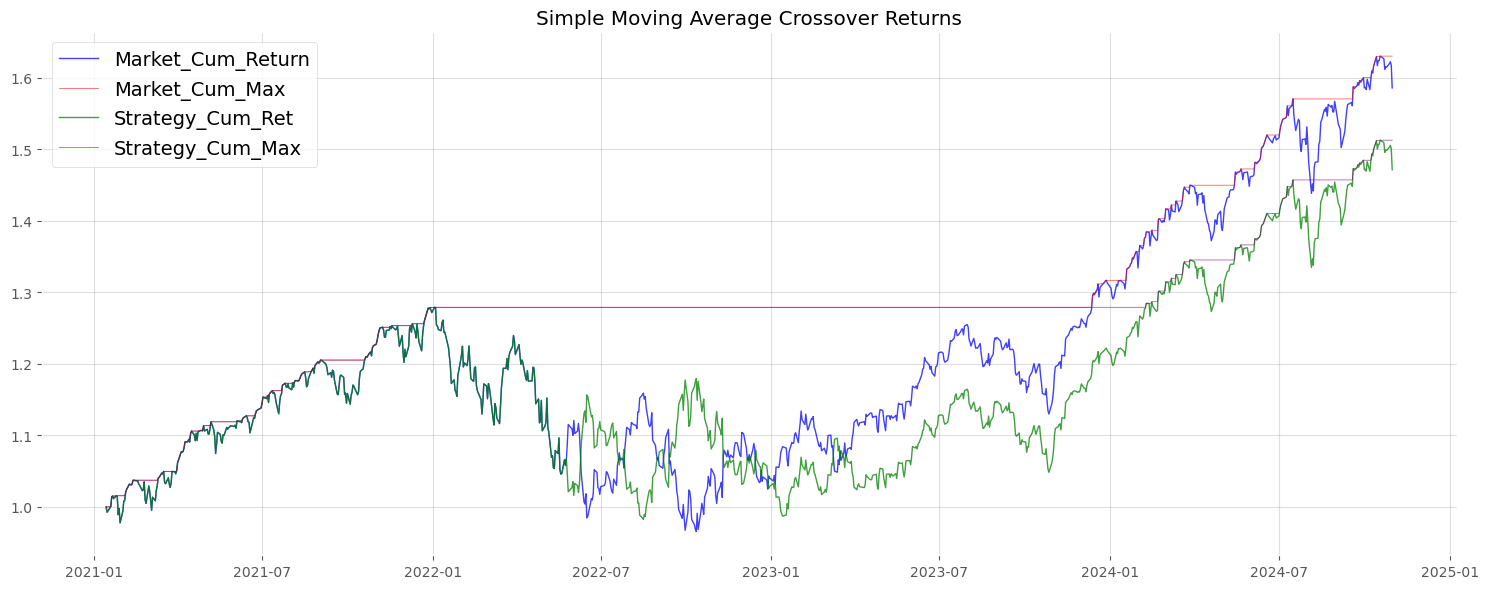

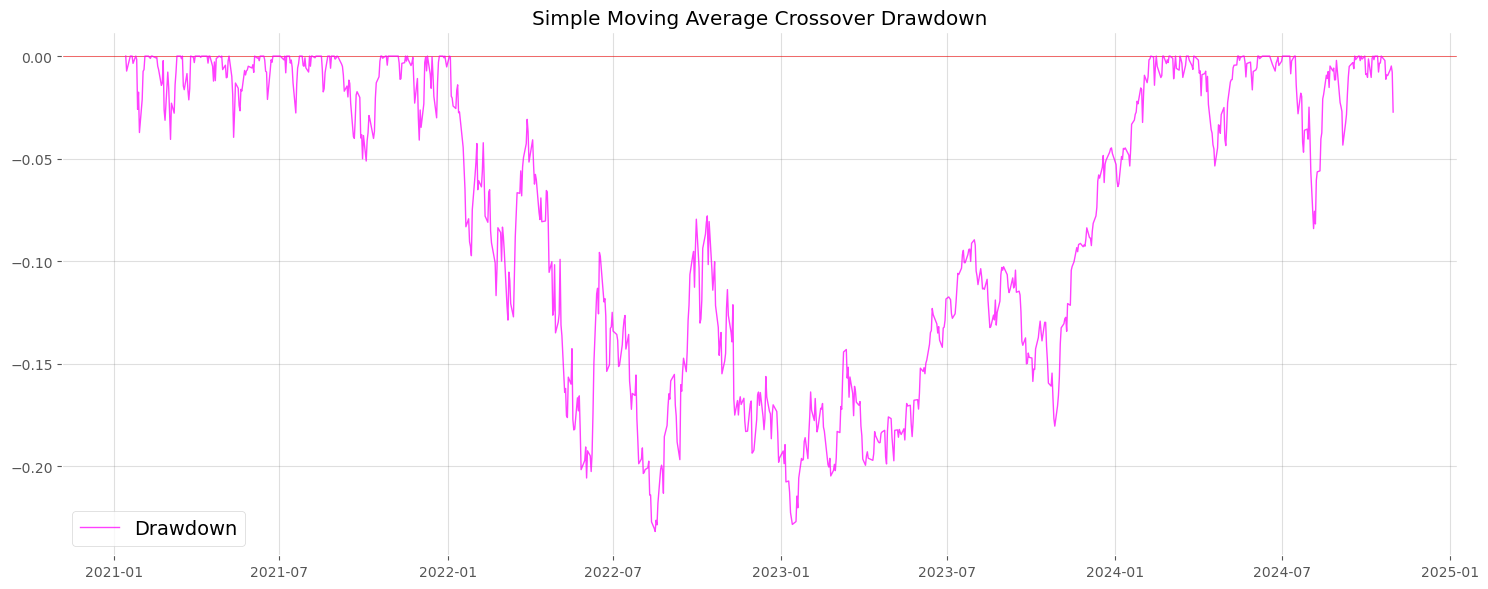

Running `Exponential Moving Average Crossover` Strategy on period 2021-01-14 to 2024-10-31
Sharpe Ratio: 0.49
Compound Annual Growth Rate: 7.00%
Max Drawdown: 29.30%
Money Left in Account: 129,304.87
Cumulative Portfolio Return: 29.30%


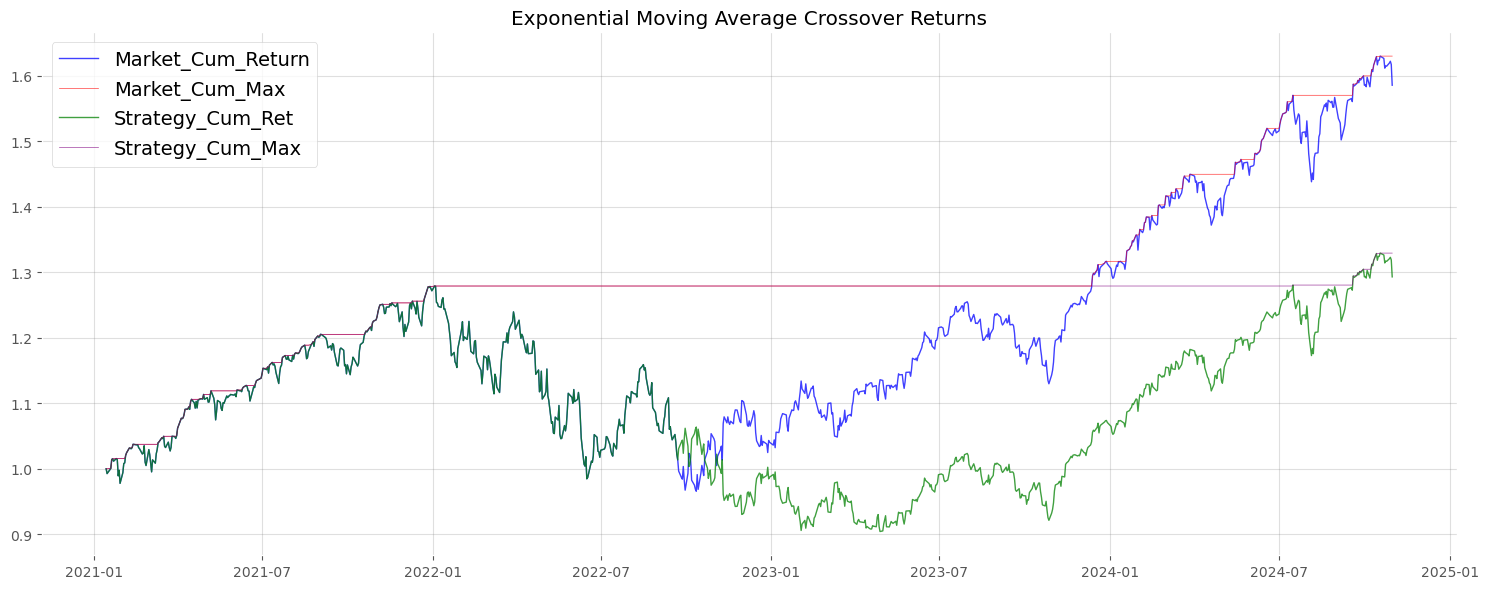

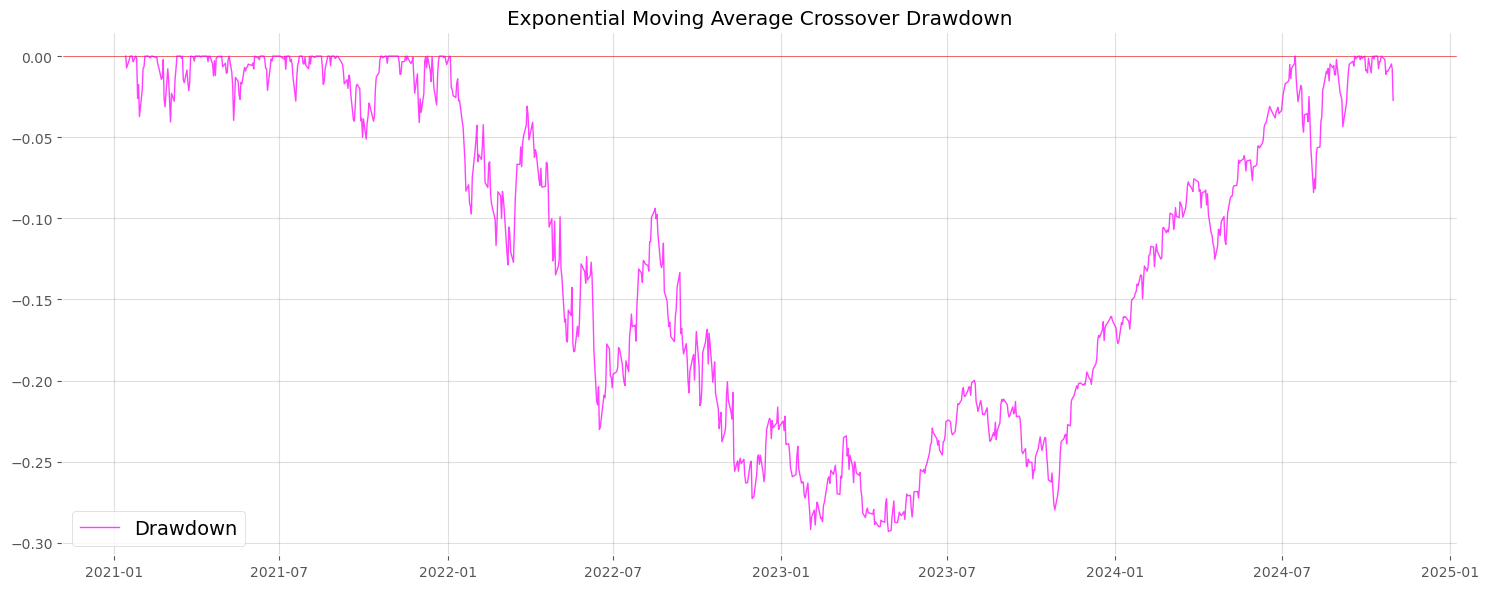

Running `MACD` Strategy on period 2021-01-14 to 2024-10-31
Sharpe Ratio: 0.17
Compound Annual Growth Rate: 1.51%
Max Drawdown: 31.10%
Money Left in Account: 105,875.45
Cumulative Portfolio Return: 5.88%


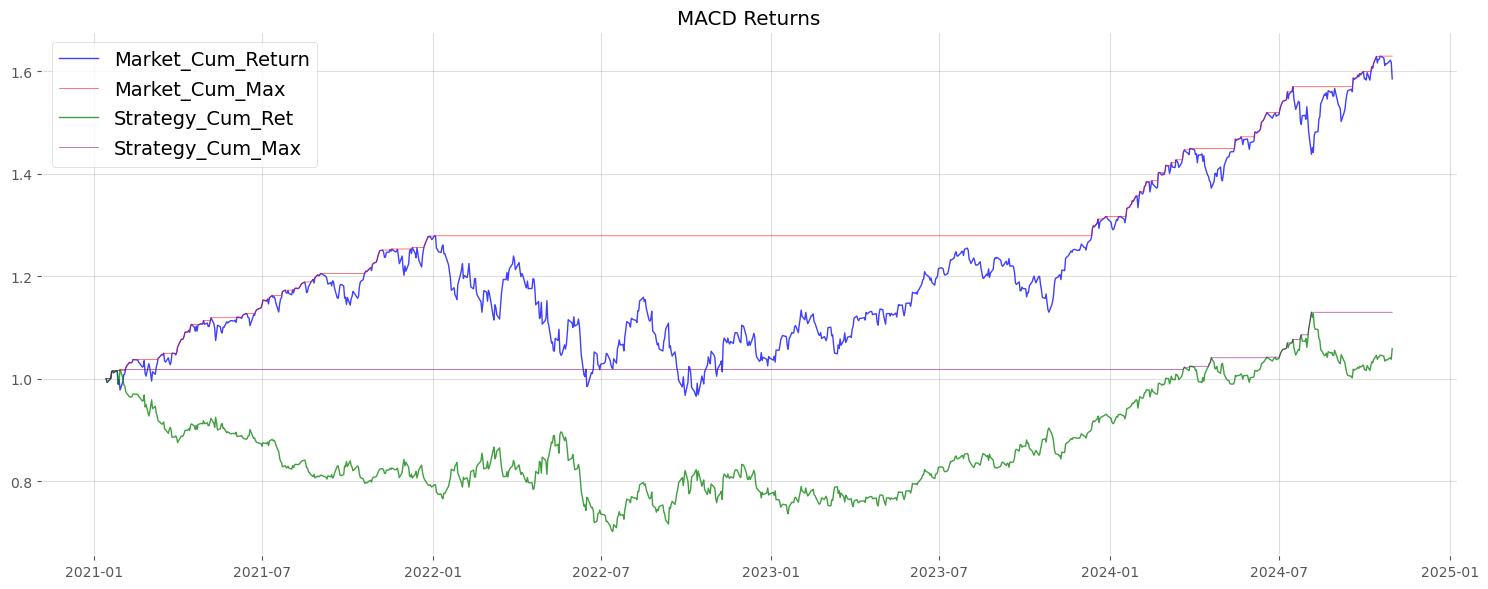

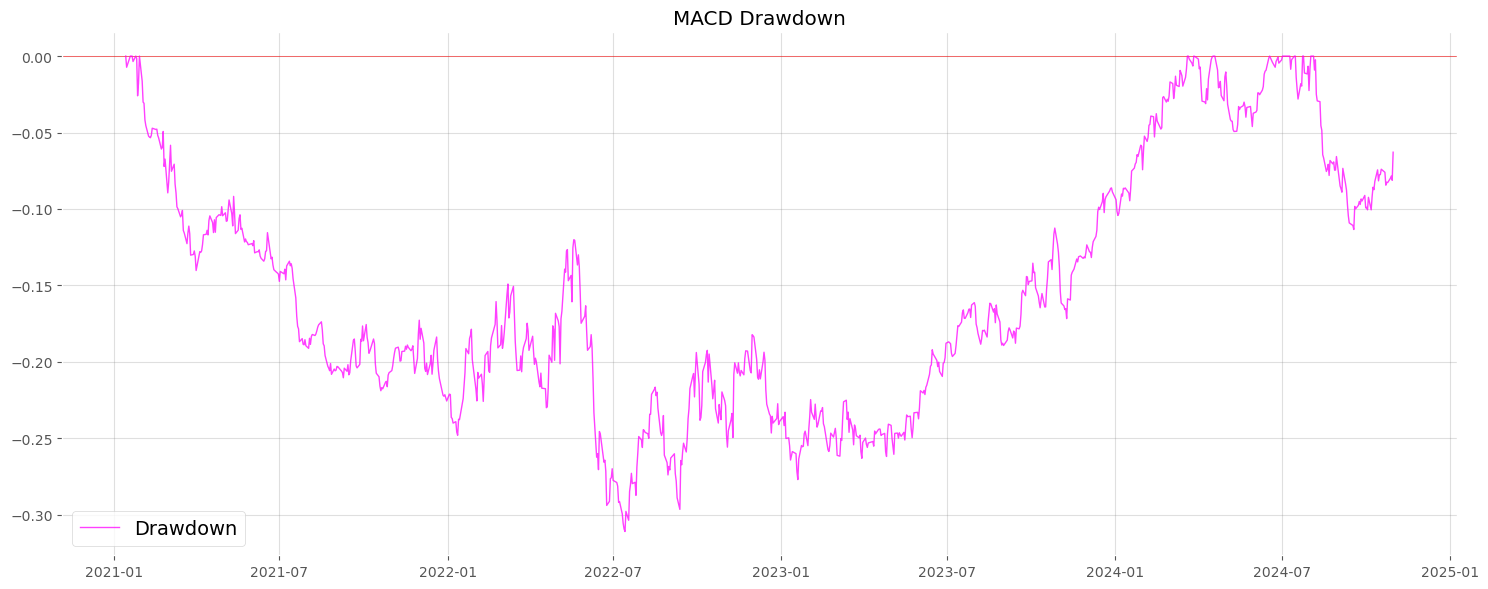

Running `Relative Strength Index` Strategy on period 2021-01-14 to 2024-10-31
Sharpe Ratio: 0.16
Compound Annual Growth Rate: 0.90%
Max Drawdown: 17.92%
Money Left in Account: 103,445.33
Cumulative Portfolio Return: 3.45%


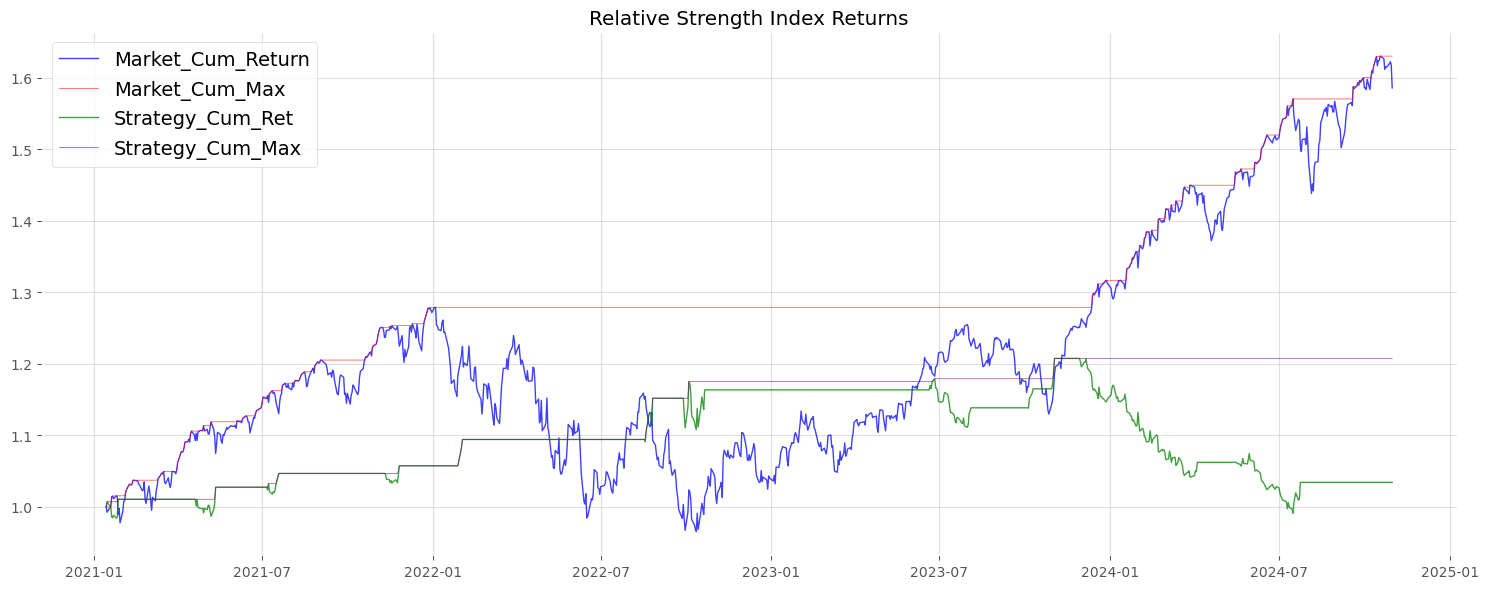

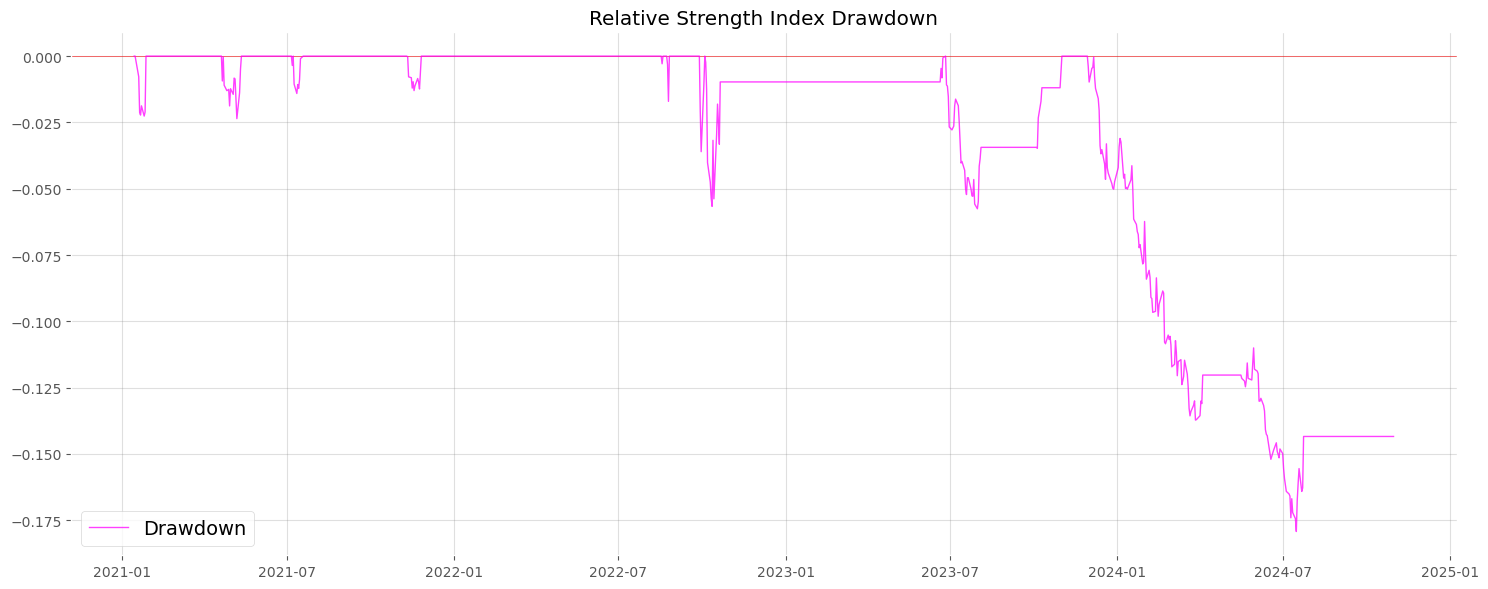

Running `Bollinger Bands` Strategy on period 2021-01-14 to 2024-10-31
Sharpe Ratio: 0.02
Compound Annual Growth Rate: -0.15%
Max Drawdown: 14.01%
Money Left in Account: 99,432.41
Cumulative Portfolio Return: -0.57%


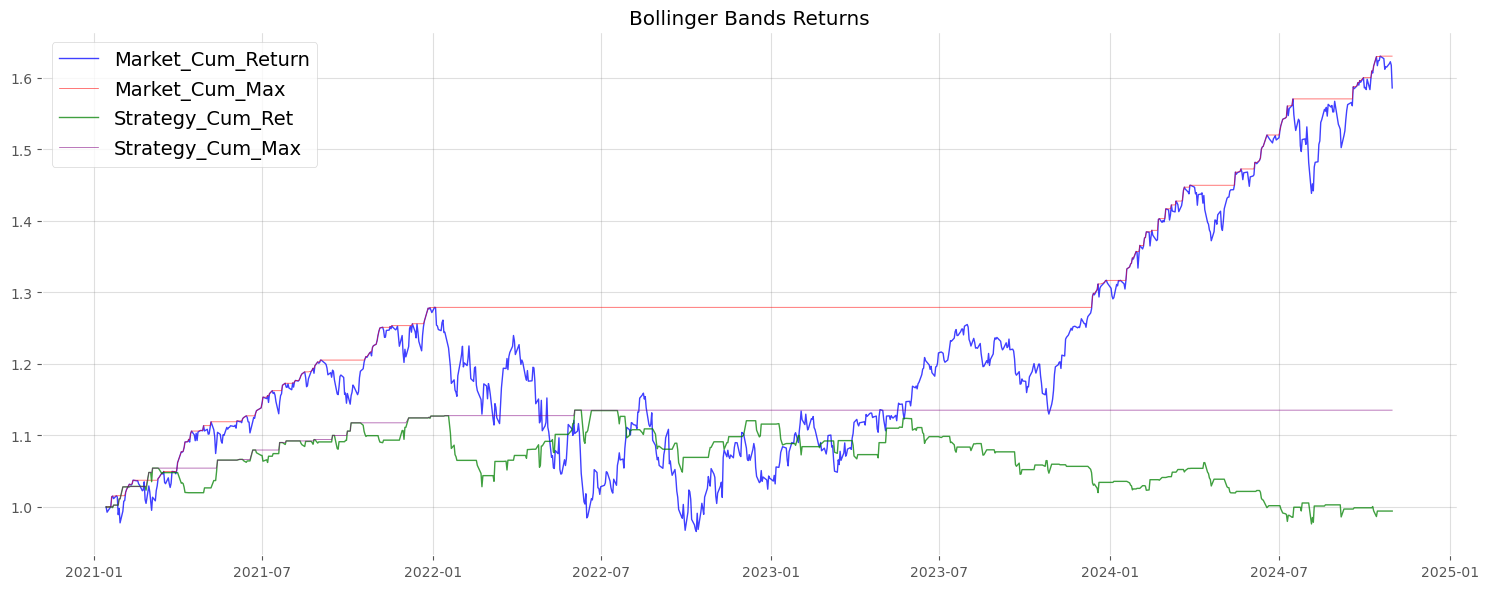

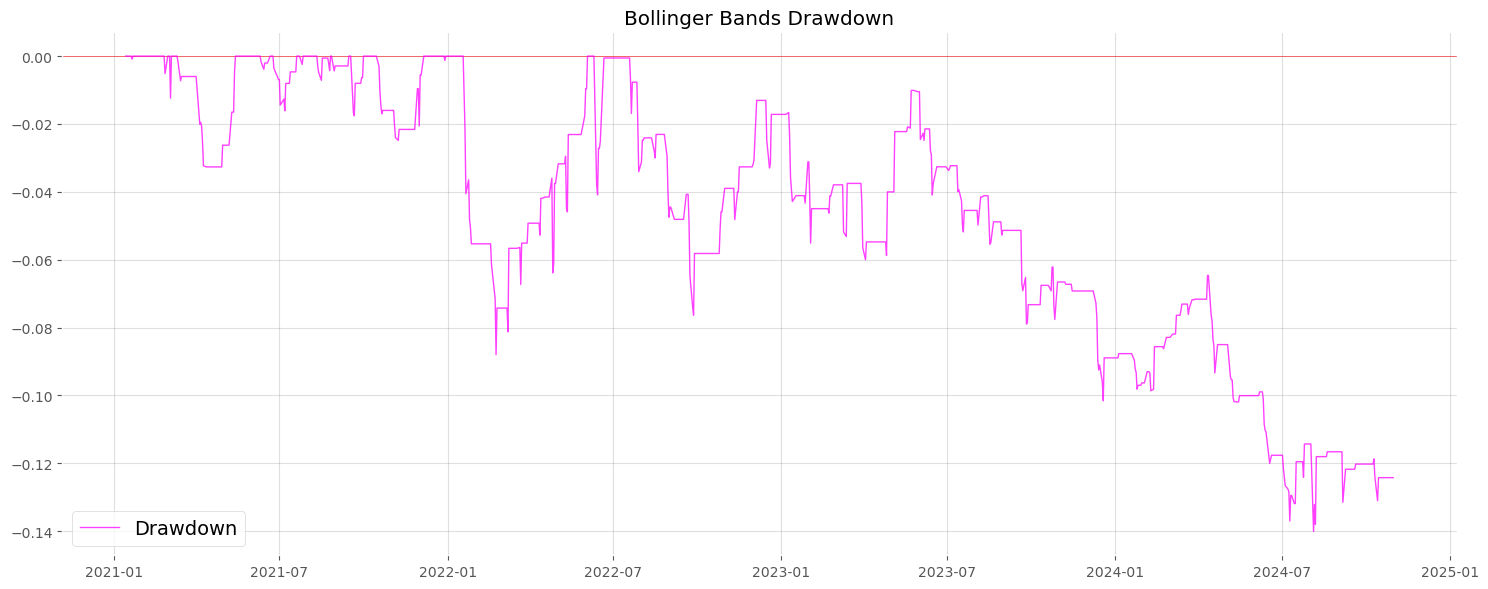

Running `Linear Regression` Strategy on period 2021-01-14 to 2024-10-31
Sharpe Ratio: 1.10
Compound Annual Growth Rate: 18.48%
Max Drawdown: 15.92%
Money Left in Account: 190,371.07
Cumulative Portfolio Return: 90.37%


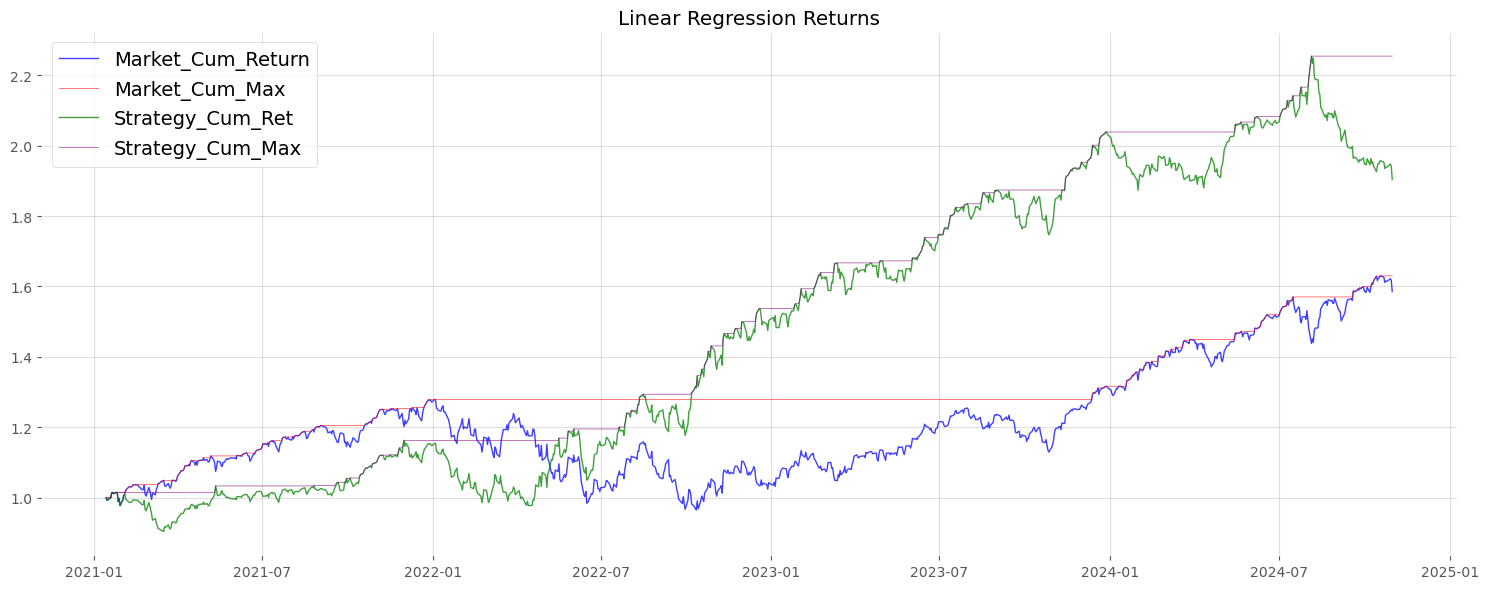

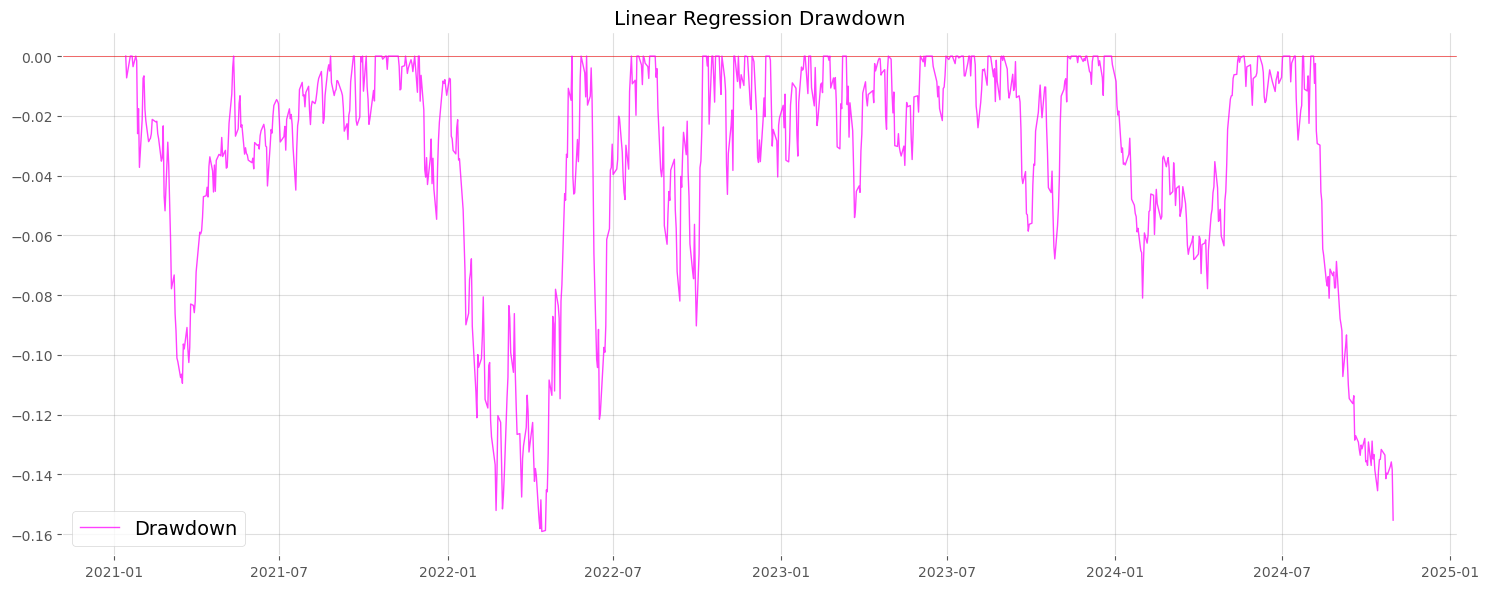

In [238]:
result_df = SMA_strategy(spy_df, short_window=short_SMA, long_window=long_SMA)
backtester = Backtester(result_df, strategy_name="Simple Moving Average Crossover")
backtester.run_backtesting()

result_df = EMA_strategy(spy_df, short_window=short_EMA, long_window=long_EMA)
backtester = Backtester(result_df, strategy_name="Exponential Moving Average Crossover")
backtester.run_backtesting()

result_df = MACD_strategy(spy_df, short_window=short_MACD, long_window=long_MACD, signal_window=signal_MACD)
backtester = Backtester(result_df, strategy_name="MACD")
backtester.run_backtesting()

rsi_period = 14
result_df = RSI_strategy(spy_df, rsi_period)
backtester = Backtester(result_df, strategy_name="Relative Strength Index")
backtester.run_backtesting()

result_df = BB_strategy(spy_df, period_BB, multiplier_BB)
backtester = Backtester(result_df, strategy_name="Bollinger Bands")
backtester.run_backtesting()

backtester = Backtester(ML, strategy_name="Linear Regression")
backtester.run_backtesting()

Running `PCA` Strategy on period 2021-01-13 to 2024-10-31
Sharpe Ratio: 1.19
Compound Annual Growth Rate: 9.92%
Max Drawdown: 6.69%
Money Left in Account: 143,261.93
Cumulative Portfolio Return: 43.26%


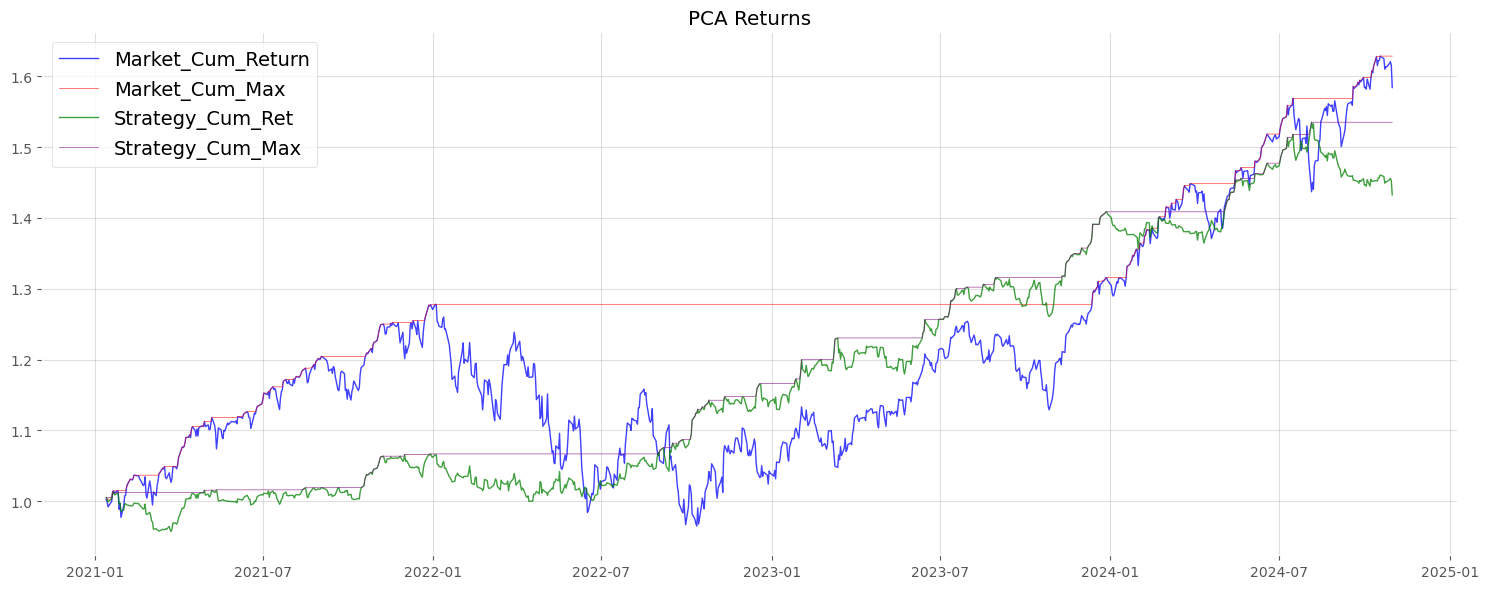

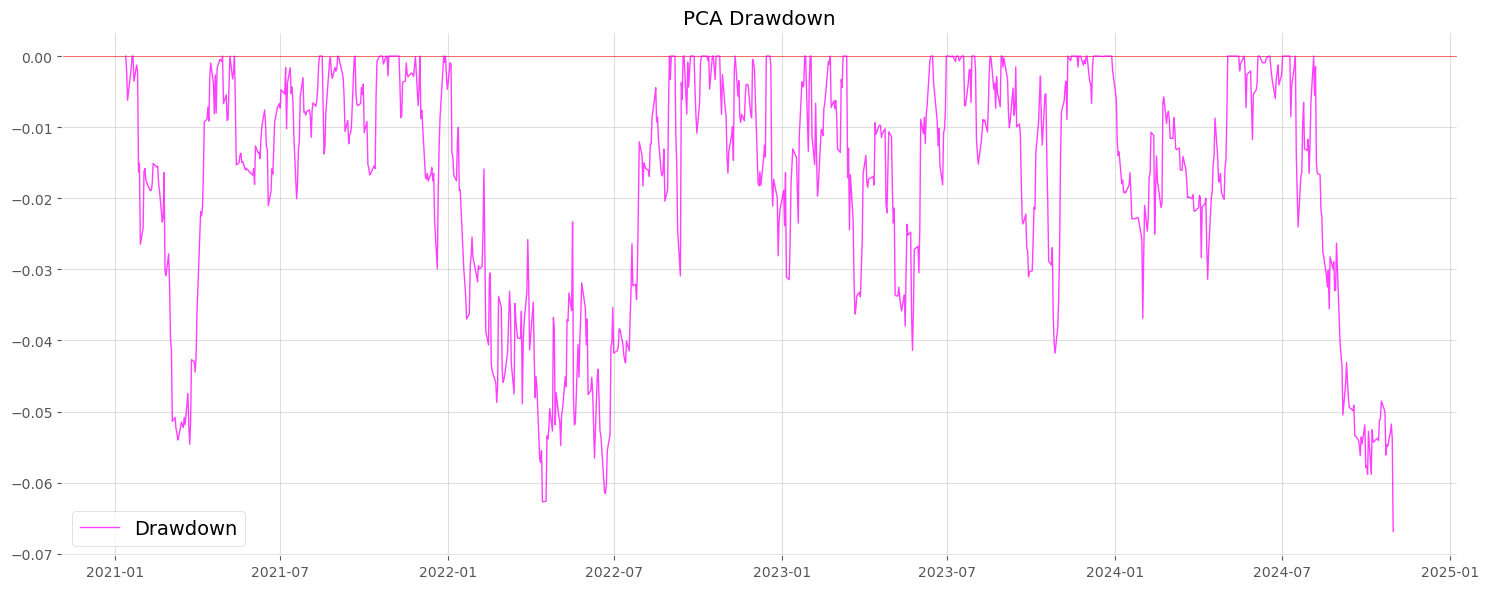

In [239]:
pca_simple_ret = np.exp(pca_df_test['strategy_log_returns']) -1
pca_sharpe_ratio = np.mean(pca_simple_ret)/np.std(pca_simple_ret) * np.sqrt(252)
num_days = (pca_df_test.index[-1] - pca_df_test.index[0]).days
pca_cagr = (pca_df_test["Portfolio_value"][-1] / 100000) ** (365.0 / num_days) - 1
pca_max_drawdown = pca_df_test["Drawdown"].min()

print(f'Running `PCA` Strategy on period '\
        + f'{pca_df_test.index[0].date()} to {pca_df_test.index[-1].date()}')

print(f'Sharpe Ratio: {pca_sharpe_ratio:.2f}')
print(f'Compound Annual Growth Rate: {pca_cagr:.2%}')
print(f'Max Drawdown: {-pca_max_drawdown:.2%}')
print(f'Money Left in Account: {pca_df_test["Portfolio_value"][-1]:,.2f}')
print(f'Cumulative Portfolio Return: {pca_df_test["Portfolio_value"][-1]/100000 -1:,.2%}')


plt.figure(figsize=(15, 6))
plt.plot(pca_df_test.index, pca_df_test['cum_returns'], label='Market_Cum_Return', color="blue", alpha=0.75, lw=1)
plt.plot(pca_df_test.index, pca_df_test['cum_max'], label='Market_Cum_Max', color="red", alpha=0.75, lw=0.5)

plt.plot(pca_df_test.index, pca_df_test['strategy_cum_returns'], label='Strategy_Cum_Ret', color="green", alpha=0.75, lw=1)
plt.plot(pca_df_test.index, pca_df_test['strategy_cum_max'], label='Strategy_Cum_Max', color="purple", alpha=0.75, lw=0.5)

plt.legend()
plt.title("PCA" + " Returns")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))
plt.axhline(0, color='red', alpha=0.75, lw=0.5)
plt.plot(pca_df_test.index, pca_df_test['Drawdown'], label='Drawdown', color="magenta", alpha=0.75, lw=1)

plt.legend()
plt.title("PCA" + " Drawdown")
plt.tight_layout()
plt.show()

<a id="part3"></a>
### Part 3 (7 points)
Third, you should write up an executive summary of your strategies and backtesting results. Please report at least your `top three strategies` (i.e., strategy A, strategy B, strategy C). In this summary, you should discuss Sharpe Ratio, compound annual growth rate, and maximum drawdown, comparing your results for strategies A, B, and C. For each of the three sections, please provide a bookmark in your Jupyter Notebook file (for easy access).
###### [Back to table of contents](#bookmark)

<a id="summary31"></a>
#### <font color = orange> Part 3.1 Linear Regression </font>

**Description**: Use Linear Regression to predict weekly returns using variables such as weekly log returns of indices, fx rates, stocks,  dependent variable at different lags and moving averages.
- Sharpe Ratio (Backtest): 1.10
- CAGR (Backtest): 18.48%
- Max. Drawdown (Backtest): 15.92%

- Sharpe Ratio (Overall): 0.89
- CAGR (Overall): 16.66%
- Max. Drawdown (Overall): 37.84%

**Money Left in Account: $1,870,288.80**
###### [Back to table of contents](#bookmark)

<a id="summary32"></a>

#### <font color = orange> Part 3.2 Simple Moving Average Crossover </font>

**Description**: Shorter Moving Average crossing above Longer Moving Average signals an uptrend and Shorter Moving Average crossing below Longer Moving Average signals a downtrend. This is a trend-following strategy. 

> Short window = 151, Long window = 152
- Sharpe Ratio (Backtest): 0.70
- CAGR (Backtest): 10.70%
- Max. Drawdown (Backtest): 23.17%

- Sharpe Ratio (Overall): 0.69
- CAGR (Overall): 12.06%
- Max. Drawdown (Overall): 33.72%

**Money Left in Account: $871,398.89**
###### [Back to table of contents](#bookmark)

<a id="summary33"></a>

#### <font color = orange>  Part 3.3 PCA </font>

**Description**: Perform PCA on the best strategies from each category, `mometum`, `mean reversion` and `ML` to get allocate weights to each strategy.

> SMA: short window = 151, long window = 152

> Bollinger Bands: MA windwo = 15, No.of std = 1.5

> Linear Regression

- Sharpe Ratio (Backtest): 1.19
- CAGR (Backtest): 9.92%
- Max. Drawdown (Backtest): 6.69%

- Sharpe Ratio (Overall): 0.93
- CAGR (Overall): 11.85%
- Max. Drawdown (Overall): 21.73%

**Money Left in Account: $841,239.39**
###### [Back to table of contents](#bookmark)


<a id="summary34"></a>

#### <font color = orange>  Part 3.4 Bollinger Bands </font>

**Description**: Bollinger Bands used to generate signals fro mean reversion strategy. When price is above the upper threshold, sell. When price is below the lower threshold, buy. Exit position when price falls within the upper and lower threshold.

> MA window = 15, No. of std = 1.5
- Sharpe Ratio (Backtest): 0.02
- CAGR (Backtest): -0.15%
- Max. Drawdown (Backtest): 14.01%

- Sharpe Ratio (Overall): 0.49
- CAGR (Overall): 4.71%
- Max. Drawdown (Overall): 20.88%

**Money Left in Account: $240,083.40**
###### [Back to table of contents](#bookmark)

<a id="part4"></a>

### Part 4 (7 points)
`Self-Critique of Your Team's Trading Strategies`

As you embark on the rigorous journey of developing and backtesting trading strategies using historical S&P 500 data, it is imperative to approach you methodologies with a critical lense. The realm of quantitative finance is fraught with complexities and subtleties that can significantly impact the performance of your strategies. A robust strategy is not merely one that has shown success in historical backtesting, but one that is also resilient to the pitfalls commonly encountered in financial modeling and forecasting.

In this phase of self-critique, your objective is to dissect and scrutinize our strategies through the lens of common biases and potential market shifts. This process is not just a mere exercise in due diligence; it is a fundamental step in ensuring that our strategies are not only theoretically sound but also practically viable in the dynamic and often unpredictable real-world financial markets.

When reviewing your trading strategies, it’s vital to consider various factors that could impact their performance. Issues such as survivorship bias, lookahead bias, and the implications of market regime shifts are not just theoretical concerns; they are real-world phenomena that can significantly skew your strategies, potentially leading to misleading conclusions about their effectiveness. Below, you’ll find some sample self-critiques that you could use as a starting point for evaluating your trading strategies. These examples are designed to help initiate the process of self-critique and ensure a comprehensive analysis of your approach.

###### [Back to table of contents](#bookmark)

<a id="critique41"></a>

#### <font color = orange> Part 4.1 Momentum and Mean Reversion Critique </font>

> ##### Market Regime Dependency
The strategy might perform well in trending markets but could fail during sideways or choppy conditions. Prolonged choppy/ranging markets can result in huge drawdowns

###### [Back to table of contents](#bookmark)

> ##### SMA Strategy
The SMA is a straightforward approach to smoothing price data over a fixed period, but it often lags behind market trends, particularly during rapid price movements. This delay can cause traders to enter or exit positions late, reducing profitability. Moreover, the SMA does not weigh recent data more heavily, which can make it less responsive to sudden market changes. Its reliance on a fixed time window also introduces challenges in adapting to varying market conditions, as shorter windows may produce too many false signals while longer windows might overlook significant short-term trends.

###### [Back to table of contents](#bookmark)

> ##### EMA Strategy
EMA addresses some of SMA’s issues by assigning greater weight to recent prices, allowing it to respond more quickly to market changes. However, this responsiveness also makes it more prone to noise and false signals, especially in volatile markets. The sensitivity of the EMA can lead to over-trading if not carefully calibrated, and determining the optimal weighting factor or time period can be subjective and vary across assets and timeframes. This makes the EMA less reliable in consolidating markets, where price movements are more erratic and less trend-driven.

###### [Back to table of contents](#bookmark)

> ##### MACD Strategy
MACD builds on moving averages by analyzing the convergence and divergence of two EMAs, along with a signal line to generate buy or sell signals. While it is a versatile tool that combines trend-following and momentum analysis, MACD often lags in volatile or sideways markets, leading to misleading signals. Its reliance on historical price data also means it cannot predict trend reversals but merely confirms them after they have occurred. Furthermore, MACD requires proper parameter tuning (e.g., fast and slow EMA periods) to avoid overfitting to specific datasets, which can make it less effective in dynamic or rapidly changing markets.

###### [Back to table of contents](#bookmark)

> ##### RSI Strategy
The RSI is a momentum oscillator that measures the speed and change of price movements to determine whether an asset is overbought or oversold. While it is a valuable tool for identifying potential reversal points, it often struggles in trending markets. In strong uptrends, the RSI can remain overbought for extended periods, and in strong downtrends, it can remain oversold. This can lead to premature entries or exits, as the RSI fails to account for the persistence of trends. Additionally, the standard RSI settings (e.g., 14 periods) may not be suitable for all market conditions or asset classes, requiring constant adjustment to balance sensitivity and reliability. False signals are also common, especially in volatile markets where sharp price swings can cause the RSI to fluctuate without any meaningful reversal in trend.

###### [Back to table of contents](#bookmark)

> ##### Bollinger Bands Strategy
Bollinger Bands, on the other hand, use standard deviations around a moving average to define a range of expected price movement, identifying overbought or oversold levels when prices touch or breach the bands. While they are effective in capturing periods of high and low volatility, their reliance on historical price data can make them reactive rather than predictive. Bollinger Bands often perform poorly in trending markets, where prices may consistently “ride the band” without reversing. This can mislead traders into assuming mean reversion will occur, resulting in continued losses. Additionally, the choice of parameters (e.g., the period for the moving average or the number of standard deviations) can significantly influence the bands’ effectiveness, often requiring subjective tuning. The strategy is also highly susceptible to market noise, as minor price fluctuations can generate false signals, leading to over-trading and increased transaction costs.

###### [Back to table of contents](#bookmark)

<a id="critique42"></a>

#### <font color = orange> Part 4.2 Machine Learning Critique </font>

> ##### Regression based strategy
Supervised ML models tend to learn patterns specific to the training data, especially when the dataset includes noise or spurious correlations. In trading, past performance does not guarantee future results. These models focus on correlation rather than causation, often relying on historical relationships that may not reflect genuine causal mechanisms. Once trained, these models are static and may struggle to adapt quickly to new regimes without frequent retraining, which itself can introduce risks. They require careful selection of hyperparameters for optimal performance. Improper tuning or reliance on default parameters can lead to suboptimal results, while over-tuning risks creating models that are brittle and overly sensitive to slight changes in the data.

Financial returns are close to a random walk, making it difficult for linear regression to consistently predict direction.

Overfitting and multicollinearity issues due to the use of a large number of variables and some variables llikely to be highly correlated with each other, e.g. Moving Averages of different window lengths. May be highly sensitive to small change in one variable.

Lookahead bias risk may be present as certain data points may not have been immediately available or finalized at the time of the prediction. While we have taken steps such as lagging the variables to mitigate lookahead bias, discrepancies between finalized historical data and real-time preliminary data may still lead to differences in prediction performance.

Market regime shifts may lead to poor generalization of the Linear Regression model as it assumes that relationships between predictors and returns remain stable over time. May need to train the model on various market regimes and apply the appropriate linear regression model when the regime is detected.


###### [Back to table of contents](#bookmark)

> ##### PCA based strategy

Unsupervised ML focuses on identifying patterns and structures in the data rather than making predictions.

Poorly preprocessed data can distort the results, leading to misleading components or clusters that have no real-world significance. PCA can become computationally expensive when applied to large-scale datasets making it less practical for real-time or high-frequency trading applications and may limit its scalability. 

PCA weights might become outdated over time, requiring frequent recalibration or rebalancing to reflect evolving market conditions and correlations. Optimal timing or rules such as regime detection mechanisms would need to be in place to trigger portfolio rebalancing.

###### [Back to table of contents](#bookmark)

<a id="contribution"></a>

#### <font color= green> Part 4.3 Contribution Statement </font>

###### [Back to table of contents](#bookmark)

**GUAN HONGYANG**: Developed Momentum and Mean Reversion trading strategies in `Part 1`. Key coordinator of the project; responsible for scheduling meetings, assigning work, aligning the team and keeping members on track. Jointly summarize self critiques in `Part 4`

**YEE LIH YING, RACHEL**: Developed the machine learning trading strategies (Assortment of models and PCA) in `Part 1`. Responsible for hyperparameter tuning of the Momentum and Mean Reversion trading strategies to maximize cumulative returns. Wrote `Part 3`. Jointly summarized self critiques in `Part 4`.

**NIRALA, PRAKASH CHANDRA**: Developed the code for Backtesting in `Part 2` to generate performance metrics and plots. Ran the performance evaluation of strategies over entire 20 years period and strategy backtesting over the latest 20% of data to collate the results for summarizing and finding strategies producing better outcome in both the cases. Jointly summarized self critiques in `Part 4`. Added the table of contents and the hyperlinks to different sections of notebook for conenient and seamless navigation.